# PINN HPO: HPO for Physics-Informed Neural Networks (REAL PyTorch Training)

Self-contained Colab notebook â€” **real PyTorch PINN training** (autograd physics
residuals, real MLP models, real optimizers), ported verbatim from this repo's
`src/training/benchmark_factory.py`, `src/models/mlp.py`, and `src/benchmarks/*`.
No synthetic/placeholder metrics for ODE, Heat, Burgers, or Wave.

Benchmarks comparing 9 metaheuristics:
- **GA**, **PSO**, **ACO**, **GSA**
- **Fuzzy-GA**, **Fuzzy-PSO**, **Fuzzy-ACO**, **Fuzzy-GSA** (Mamdani fuzzy controller adapts search parameters)
- **F-MAGSO** (novel fuzzy-guided multi-stage gravitational/swarm hybrid)

**Task Breakdown:** 9 algorithms Ã— 4 benchmarks (ODE, Heat, Burgers, Wave) Ã— 3 seeds
= **108 real optimization tasks**, plus reporting/analysis (run log, convergence,
diversity, radar, heatmaps, generation-wise diversity-vs-accuracy) = **~115 total**.

**IMPORTANT â€” set `QUICK_MODE = True` first** to smoke-test the whole pipeline in a
few minutes before committing to the full multi-hour run (Cell "Configuration" below).

**Estimated full-run time:** longer than a first-pass estimate would suggest — the run length (generations/iterations/evals) has been doubled for every algorithm (~160-204 PINN training calls per algorithm/benchmark/seed cell, 1200 steps each) and the architecture search space has been enlarged (up to 10 hidden layers, 512 width), so individual PINN trainings are also more expensive. Budget considerably more than a single T4 GPU day for the full 9-algorithm x 4-benchmark x 3-seed grid. Enable GPU: **Runtime → Change runtime type → T4 GPU**.

In [ ]:
import subprocess, sys

packages = ["torch", "numpy", "scipy", "matplotlib", "tqdm"]
for pkg in packages:
    try:
        __import__(pkg)
        print(f"already installed: {pkg}")
    except ImportError:
        print(f"installing: {pkg}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("\nAll dependencies ready.")

already installed: torch
already installed: numpy
already installed: scipy
already installed: matplotlib
already installed: tqdm

All dependencies ready.


In [ ]:
import os, json, time
from pathlib import Path
from dataclasses import dataclass, asdict, replace
from typing import Any
from functools import lru_cache
import warnings

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")

# Mount Google Drive so results persist even if Colab disconnects mid-run
# (a full benchmark run can take 5-10 hours; /content alone is wiped on disconnect).
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    OUTPUT_DIR = "/content/drive/MyDrive/pinn_hpo_results"
    print("Google Drive mounted -- results will be saved to:", OUTPUT_DIR)
except ImportError:
    OUTPUT_DIR = "/content/pinn_hpo_results"
    print("Not running in Colab -- results will be saved locally to:", OUTPUT_DIR)
Path(OUTPUT_DIR).mkdir(exist_ok=True, parents=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
if DEVICE == "cpu":
    print("WARNING: no GPU detected. Runtime -> Change runtime type -> GPU (T4) is strongly recommended.")
print(f"Output directory: {OUTPUT_DIR}")

Mounted at /content/drive
Google Drive mounted -- results will be saved to: /content/drive/MyDrive/pinn_hpo_results
Using device: cpu
Output directory: /content/drive/MyDrive/pinn_hpo_results


In [ ]:
# ---- Publication/research-grade plot styling ----
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "lines.linewidth": 2.0,
    "lines.markersize": 5,
})
ALGO_COLORS = {}  # populated once ALGORITHMS is known (Configuration cell)
print("Publication-style plotting configured (serif fonts, 300 DPI figures).")

Publication-style plotting configured (serif fonts, 300 DPI figures).


In [ ]:
def set_seed(seed: int):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def ensure_dir(path: str):
    Path(path).mkdir(parents=True, exist_ok=True)

def save_json(path: str, data: dict):
    ensure_dir(str(Path(path).parent))
    with open(path, 'w') as f:
        json.dump(data, f, indent=2, default=str)

In [ ]:
@dataclass(frozen=True)
class SearchSpace:
    hidden_layers_min: int = 1
    hidden_layers_max: int = 10   # enlarged from 6: allow deeper networks (applies to all 9 algorithms equally)
    hidden_width_min: int = 8
    hidden_width_max: int = 512   # enlarged from 256: allow wider networks (applies to all 9 algorithms equally)
    activations: tuple = ("tanh", "sine", "swish")
    optimizers: tuple = ("adam", "adamw", "lbfgs")
    lr_min: float = 1e-4
    lr_max: float = 5e-2
    w_phys_min: float = 0.1
    w_phys_max: float = 10.0
    w_ic_min: float = 0.1
    w_ic_max: float = 50.0
    n_collocation_min: int = 64
    n_collocation_max: int = 1024

    def get_bounds(self):
        lb = np.array([
            float(self.hidden_layers_min), float(self.hidden_width_min), 0.0, 0.0,
            float(np.log10(self.lr_min)), float(self.w_phys_min),
            float(self.w_ic_min), float(self.n_collocation_min)
        ], dtype=float)
        ub = np.array([
            float(self.hidden_layers_max), float(self.hidden_width_max),
            float(len(self.activations) - 1), float(len(self.optimizers) - 1),
            float(np.log10(self.lr_max)), float(self.w_phys_max),
            float(self.w_ic_max), float(self.n_collocation_max)
        ], dtype=float)
        return lb, ub

def clip_int(x, lo, hi):
    return max(lo, min(hi, int(round(float(x)))))

def clip_float(x, lo, hi):
    return max(lo, min(hi, float(x)))

def choose_activation(idx, activations):
    i = max(0, min(len(activations) - 1, int(round(float(idx)))))
    return activations[i]

def choose_optimizer(idx, optimizers):
    i = max(0, min(len(optimizers) - 1, int(round(float(idx)))))
    return optimizers[i]

def decode_solution(x: np.ndarray, space: SearchSpace, base) -> "TrainConfig":
    layers = clip_int(x[0], space.hidden_layers_min, space.hidden_layers_max)
    width = clip_int(x[1], space.hidden_width_min, space.hidden_width_max)
    activation = choose_activation(x[2], space.activations)
    optimizer = choose_optimizer(x[3], space.optimizers)
    log10_lr = clip_float(x[4], np.log10(space.lr_min), np.log10(space.lr_max))
    lr = float(10 ** log10_lr)
    w_phys = clip_float(x[5], space.w_phys_min, space.w_phys_max)
    w_ic = clip_float(x[6], space.w_ic_min, space.w_ic_max)
    n_col = clip_int(x[7], space.n_collocation_min, space.n_collocation_max)
    return replace(base, hidden_layers=layers, hidden_width=width, activation=activation,
                   optimizer=optimizer, lr=lr, w_phys=w_phys, w_ic=w_ic, n_collocation=n_col)

In [ ]:
def _trimf(x, abc):
    a, b, c = abc
    x_arr = np.asarray(x, dtype=float)
    y = np.zeros_like(x_arr)
    if b != a:
        left_mask = (a <= x_arr) & (x_arr <= b)
        y[left_mask] = (x_arr[left_mask] - a) / (b - a)
    if c != b:
        right_mask = (b <= x_arr) & (x_arr <= c)
        y[right_mask] = (c - x_arr[right_mask]) / (c - b)
    y[x_arr == b] = 1.0
    y = np.clip(y, 0.0, 1.0)
    return float(y) if np.isscalar(x) else y

class FuzzyController:
    def __init__(self):
        self.div_low = (0.0, 0.0, 0.45)
        self.div_med = (0.2, 0.5, 0.8)
        self.div_high = (0.55, 1.0, 1.0)
        self.imp_stagnant = (0.0, 0.0, 0.3)
        self.imp_slow = (0.15, 0.5, 0.85)
        self.imp_fast = (0.6, 1.0, 1.0)
        self.prog_early = (0.0, 0.0, 0.45)
        self.prog_mid = (0.25, 0.5, 0.75)
        self.prog_late = (0.55, 1.0, 1.0)
        self.u_out = np.linspace(0.0, 1.0, 101)
        self.out_low = _trimf(self.u_out, (0.0, 0.0, 0.5))
        self.out_med = _trimf(self.u_out, (0.25, 0.5, 0.75))
        self.out_high = _trimf(self.u_out, (0.5, 1.0, 1.0))

    def evaluate(self, diversity, improvement_rate, iteration_progress):
        d = float(np.clip(diversity, 0.0, 1.0))
        imp = float(np.clip(improvement_rate, 0.0, 1.0))
        prog = float(np.clip(iteration_progress, 0.0, 1.0))

        mu_d_low = float(_trimf(d, self.div_low)); mu_d_med = float(_trimf(d, self.div_med)); mu_d_high = float(_trimf(d, self.div_high))
        mu_imp_stag = float(_trimf(imp, self.imp_stagnant)); mu_imp_slow = float(_trimf(imp, self.imp_slow)); mu_imp_fast = float(_trimf(imp, self.imp_fast))
        mu_prog_early = float(_trimf(prog, self.prog_early)); mu_prog_mid = float(_trimf(prog, self.prog_mid)); mu_prog_late = float(_trimf(prog, self.prog_late))

        r1 = min(mu_d_low, mu_imp_stag)
        r2 = min(mu_d_high, mu_imp_fast)
        r3 = mu_prog_early
        r4 = min(mu_prog_late, mu_imp_stag)
        r5 = min(mu_prog_late, mu_imp_fast)
        r6 = min(mu_d_med, mu_imp_slow)
        r7 = mu_prog_mid

        exp_high = max(r1, r3); exp_med = max(r4, r6, r7); exp_low = max(r2, r5)
        agg_exp = np.maximum(np.minimum(exp_high, self.out_high),
                    np.maximum(np.minimum(exp_med, self.out_med), np.minimum(exp_low, self.out_low)))

        expt_high = max(r2, r4, r5); expt_med = max(r3, r6, r7); expt_low = r1
        agg_expt = np.maximum(np.minimum(expt_high, self.out_high),
                    np.maximum(np.minimum(expt_med, self.out_med), np.minimum(expt_low, self.out_low)))

        sum_exp = np.sum(agg_exp)
        exploration = float(np.sum(self.u_out * agg_exp) / sum_exp) if sum_exp > 1e-9 else 0.5
        sum_expt = np.sum(agg_expt)
        exploitation = float(np.sum(self.u_out * agg_expt) / sum_expt) if sum_expt > 1e-9 else 0.5
        return exploration, exploitation

def compute_population_diversity(population, lb, ub):
    if len(population) <= 1:
        return 0.0
    norm_pop = (population - lb) / (ub - lb + 1e-12)
    centroid = np.mean(norm_pop, axis=0)
    distances = np.linalg.norm(norm_pop - centroid, axis=1)
    max_d = np.sqrt(norm_pop.shape[1]) * 0.5
    div = float(np.mean(distances) / (max_d + 1e-12))
    return float(np.clip(div, 0.0, 1.0))

In [ ]:
# ---- Real MLP model (verbatim port of src/models/mlp.py) ----
class Sine(nn.Module):
    def forward(self, x):
        return torch.sin(x)

def _activation(name: str) -> nn.Module:
    name = name.lower()
    if name == "tanh": return nn.Tanh()
    if name in {"silu", "swish"}: return nn.SiLU()
    if name == "relu": return nn.ReLU()
    if name == "sine": return Sine()
    raise ValueError(f"Unknown activation: {name}")

class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden_layers, hidden_width, activation="tanh"):
        super().__init__()
        act = _activation(activation)
        layers = []
        last = in_dim
        for _ in range(int(hidden_layers)):
            layers.append(nn.Linear(last, int(hidden_width)))
            layers.append(act)
            last = int(hidden_width)
        layers.append(nn.Linear(last, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# ---- Real benchmark classes (verbatim port of src/benchmarks/*) ----
@dataclass(frozen=True)
class ExponentialDecayBenchmark:
    """ODE: y'(t) = -y(t), y(t0)=y0. Analytic: y(t)=y0*exp(-(t-t0))."""
    t0: float = 0.0
    t1: float = 5.0
    y0: float = 1.0

    def y_true(self, t):
        t = np.asarray(t, dtype=float)
        return self.y0 * np.exp(-(t - self.t0))

    def residual(self, t, y, dy_dt):
        return dy_dt + y


@dataclass(frozen=True)
class HeatEquationBenchmark:
    """1D Heat: u_t = alpha*u_xx. Analytic: sin(pi*x/L)*exp(-alpha*pi^2*t/L^2)."""
    x0: float = 0.0
    x1: float = 1.0
    t1: float = 1.0
    alpha: float = 0.1

    def domain(self):
        return ((self.x0, self.x1), (0.0, self.t1))

    def initial_condition(self, x):
        L = self.x1 - self.x0
        return np.sin(np.pi * (x - self.x0) / L)

    def boundary_conditions(self, t):
        return np.zeros_like(t), np.zeros_like(t)

    def analytic_solution(self, x, t):
        L = self.x1 - self.x0
        return np.sin(np.pi * (x - self.x0) / L) * np.exp(-self.alpha * np.pi**2 * t / L**2)

    def residual(self, x, t, u, u_t, u_xx):
        return u_t - self.alpha * u_xx


@dataclass(frozen=True)
class Burgers1DBenchmark:
    """1D viscous Burgers: u_t + u*u_x = nu*u_xx. No closed form -> FD reference."""
    x0: float = -1.0
    x1: float = 1.0
    t1: float = 1.0
    nu: float = 0.01

    def domain(self):
        return ((self.x0, self.x1), (0.0, self.t1))

    def initial_condition(self, x):
        return np.sin(np.pi * x)

    def boundary_conditions(self, t):
        return np.zeros_like(t), np.zeros_like(t)

    def residual(self, x, t, u, u_t, u_x, u_xx):
        return u_t + u * u_x - self.nu * u_xx


@dataclass(frozen=True)
class WaveEquationBenchmark:
    """1D Wave: u_tt = c^2*u_xx. Analytic: sin(pi*x/L)*cos(c*pi*t/L)."""
    x0: float = 0.0
    x1: float = 1.0
    t1: float = 2.0
    c: float = 1.0

    def domain(self):
        return ((self.x0, self.x1), (0.0, self.t1))

    def initial_condition_u(self, x):
        L = self.x1 - self.x0
        return np.sin(np.pi * (x - self.x0) / L)

    def initial_condition_u_t(self, x):
        return np.zeros_like(x)

    def boundary_conditions(self, t):
        return np.zeros_like(t), np.zeros_like(t)

    def analytic_solution(self, x, t):
        L = self.x1 - self.x0
        return np.sin(np.pi * (x - self.x0) / L) * np.cos(self.c * np.pi * t / L)

    def residual(self, x, t, u, u_tt, u_xx):
        return u_tt - self.c**2 * u_xx


def get_benchmark(benchmark_type: str):
    return {
        "ode": ExponentialDecayBenchmark(),
        "heat": HeatEquationBenchmark(),
        "burgers": Burgers1DBenchmark(),
        "wave": WaveEquationBenchmark(),
    }[benchmark_type]

print("Real MLP model and benchmark classes loaded.")

Real MLP model and benchmark classes loaded.


In [ ]:
@dataclass(frozen=True)

class TrainConfig:

    seed: int = 0

    device: str = DEVICE

    benchmark_type: str = "ode"

    t0: float = 0.0

    t1: float = 5.0

    n_eval: int = 200

    hidden_layers: int = 3

    hidden_width: int = 32

    activation: str = "tanh"

    optimizer: str = "adam"

    lbfgs_max_iter: int = 3

    lr: float = 1e-3

    n_steps: int = 1200

    n_collocation: int = 256

    w_phys: float = 1.0

    w_ic: float = 10.0





def _make_optimizer(model, cfg):

    opt_name = cfg.optimizer.lower()

    if opt_name == "adam":

        return torch.optim.Adam(model.parameters(), lr=float(cfg.lr)), False

    elif opt_name == "adamw":

        return torch.optim.AdamW(model.parameters(), lr=float(cfg.lr)), False

    elif opt_name == "lbfgs":

        # history_size capped at 10 (PyTorch default is 100): the two-loop recursion
        # sweeps the FULL parameter vector history_size times per single .step() call.
        # With the enlarged architecture (up to 10 layers / 512 width, ~2.4M params),
        # the default history_size=100 makes LBFGS candidates catastrophically slow
        # (~3x slower confirmed empirically) -- capping it keeps L-BFGS usable regardless
        # of which architecture the search happens to sample.
        return torch.optim.LBFGS(model.parameters(), lr=float(cfg.lr),
                                  max_iter=int(cfg.lbfgs_max_iter), history_size=10), True

    else:

        raise ValueError(f"Unsupported optimizer: {cfg.optimizer}")





def _run_optimization(opt, use_lbfgs, compute_loss_fn, n_steps):

    last_loss = None

    if use_lbfgs:

        for _ in range(int(n_steps)):

            def closure():

                opt.zero_grad()

                loss = compute_loss_fn()

                loss.backward()

                return loss

            loss_tensor = opt.step(closure)

            last_loss = float(loss_tensor.detach().cpu().item())

    else:

        for _ in range(int(n_steps)):

            opt.zero_grad(set_to_none=True)

            loss = compute_loss_fn()

            loss.backward()

            opt.step()

            last_loss = float(loss.detach().cpu().item())

    return last_loss





def _bilinear_interp(x_grid, t_grid, values, x_query, t_query):

    xi = np.clip(np.searchsorted(x_grid, x_query) - 1, 0, len(x_grid) - 2)

    ti = np.clip(np.searchsorted(t_grid, t_query) - 1, 0, len(t_grid) - 2)

    x0v, x1v = x_grid[xi], x_grid[xi + 1]

    t0v, t1v = t_grid[ti], t_grid[ti + 1]

    wx = (x_query - x0v) / (x1v - x0v + 1e-12)

    wt = (t_query - t0v) / (t1v - t0v + 1e-12)

    v00 = values[ti, xi]; v01 = values[ti, xi + 1]; v10 = values[ti + 1, xi]; v11 = values[ti + 1, xi + 1]

    v0 = v00 * (1 - wx) + v01 * wx

    v1 = v10 * (1 - wx) + v11 * wx

    return v0 * (1 - wt) + v1 * wt





@lru_cache(maxsize=8)

def _burgers_fd_reference(bench, nx=201, nt_min=400):

    """Explicit FD reference solution for Burgers' (no closed form exists)."""

    x0, x1 = bench.x0, bench.x1

    t1 = bench.t1

    nu = bench.nu

    x = np.linspace(x0, x1, nx)

    dx = x[1] - x[0]

    u = bench.initial_condition(x).astype(np.float64)

    u[0] = 0.0; u[-1] = 0.0

    dt_diff = dx * dx / (2.0 * nu + 1e-8)

    dt_conv = dx / (np.max(np.abs(u)) + 1e-6)

    dt = 0.4 * min(dt_diff, dt_conv)

    nt = max(int(nt_min), int(np.ceil(t1 / dt)) + 1)

    dt = t1 / nt

    history = np.zeros((nt + 1, nx), dtype=np.float64)

    history[0] = u

    for n in range(1, nt + 1):

        u_x = np.zeros_like(u); u_x[1:-1] = (u[2:] - u[:-2]) / (2 * dx)

        u_xx = np.zeros_like(u); u_xx[1:-1] = (u[2:] - 2 * u[1:-1] + u[:-2]) / dx ** 2

        u_new = u.copy()

        u_new[1:-1] = u[1:-1] + dt * (-u[1:-1] * u_x[1:-1] + nu * u_xx[1:-1])

        u_new[0] = 0.0; u_new[-1] = 0.0

        u = u_new

        history[n] = u

    t_grid = np.linspace(0.0, t1, nt + 1)

    return x, t_grid, history





def train_pinn_ode(cfg, bench):

    device = torch.device(cfg.device if cfg.device == "cuda" and torch.cuda.is_available() else "cpu")

    model = MLP(1, 1, cfg.hidden_layers, cfg.hidden_width, cfg.activation).to(device)

    opt, use_lbfgs = _make_optimizer(model, cfg)



    rng = np.random.default_rng(cfg.seed + 123)

    t_col_np = rng.uniform(cfg.t0, cfg.t1, size=(int(cfg.n_collocation), 1)).astype(np.float32)

    t_col = torch.tensor(t_col_np, device=device, requires_grad=True)

    t0_tensor = torch.tensor([[cfg.t0]], device=device, requires_grad=True)

    y0_target = torch.tensor([[1.0]], device=device)



    def compute_loss():

        y = model(t_col)

        dy_dt = torch.autograd.grad(y, t_col, grad_outputs=torch.ones_like(y), create_graph=True, retain_graph=True)[0]

        r = bench.residual(t_col, y, dy_dt)

        loss_phys = torch.mean(r**2)

        y0_pred = model(t0_tensor)

        loss_ic = torch.mean((y0_pred - y0_target) ** 2)

        return float(cfg.w_phys) * loss_phys + float(cfg.w_ic) * loss_ic



    last_loss = _run_optimization(opt, use_lbfgs, compute_loss, cfg.n_steps)



    t_eval = np.linspace(cfg.t0, cfg.t1, int(cfg.n_eval), dtype=np.float32).reshape(-1, 1)

    y_true = bench.y_true(t_eval).reshape(-1, 1).astype(np.float32)

    with torch.no_grad():

        y_pred = model(torch.tensor(t_eval, device=device)).detach().cpu().numpy()



    err = y_pred - y_true

    mse = float(np.mean(err**2)); linf = float(np.max(np.abs(err)))

    rel_l2 = float(np.linalg.norm(err) / (np.linalg.norm(y_true) + 1e-12))

    return {"train_last_loss": last_loss, "val_mse": mse, "val_linf": linf, "val_rel_l2": rel_l2}





def train_pinn_heat(cfg, bench):

    device = torch.device(cfg.device if cfg.device == "cuda" and torch.cuda.is_available() else "cpu")

    model = MLP(2, 1, cfg.hidden_layers, cfg.hidden_width, cfg.activation).to(device)

    opt, use_lbfgs = _make_optimizer(model, cfg)



    (x0, x1), (t0, t1) = bench.domain()

    n_col = int(cfg.n_collocation)

    n_bc = max(16, n_col // 8)

    rng = np.random.default_rng(cfg.seed + 123)



    x_col = torch.tensor(rng.uniform(x0, x1, size=(n_col, 1)).astype(np.float32), device=device, requires_grad=True)

    t_col = torch.tensor(rng.uniform(t0, t1, size=(n_col, 1)).astype(np.float32), device=device, requires_grad=True)



    x_ic_np = rng.uniform(x0, x1, size=(n_bc, 1)).astype(np.float32)

    x_ic = torch.tensor(x_ic_np, device=device)

    t_ic = torch.zeros_like(x_ic)

    ic_target = torch.tensor(bench.initial_condition(x_ic_np).astype(np.float32), device=device)



    t_bc_np = rng.uniform(t0, t1, size=(n_bc, 1)).astype(np.float32)

    t_bc = torch.tensor(t_bc_np, device=device)

    x_bc0 = torch.full_like(t_bc, x0); x_bc1 = torch.full_like(t_bc, x1)

    bc0_np, bc1_np = bench.boundary_conditions(t_bc_np)

    bc0_target = torch.tensor(np.asarray(bc0_np, dtype=np.float32), device=device)

    bc1_target = torch.tensor(np.asarray(bc1_np, dtype=np.float32), device=device)



    def compute_loss():

        u = model(torch.cat([x_col, t_col], dim=1))

        u_x = torch.autograd.grad(u, x_col, grad_outputs=torch.ones_like(u), create_graph=True, retain_graph=True)[0]

        u_xx = torch.autograd.grad(u_x, x_col, grad_outputs=torch.ones_like(u_x), create_graph=True, retain_graph=True)[0]

        u_t = torch.autograd.grad(u, t_col, grad_outputs=torch.ones_like(u), create_graph=True, retain_graph=True)[0]

        res = bench.residual(x_col, t_col, u, u_t, u_xx)

        loss_phys = torch.mean(res ** 2)

        u_ic_pred = model(torch.cat([x_ic, t_ic], dim=1))

        loss_ic = torch.mean((u_ic_pred - ic_target) ** 2)

        u_bc0_pred = model(torch.cat([x_bc0, t_bc], dim=1))

        u_bc1_pred = model(torch.cat([x_bc1, t_bc], dim=1))

        loss_bc = torch.mean((u_bc0_pred - bc0_target) ** 2) + torch.mean((u_bc1_pred - bc1_target) ** 2)

        return float(cfg.w_phys) * loss_phys + float(cfg.w_ic) * (loss_ic + loss_bc)



    last_loss = _run_optimization(opt, use_lbfgs, compute_loss, cfg.n_steps)



    n_eval = int(cfg.n_eval)

    x_eval = np.linspace(x0, x1, n_eval, dtype=np.float32)

    t_eval = np.linspace(t0, t1, n_eval, dtype=np.float32)

    Xg, Tg = np.meshgrid(x_eval, t_eval)

    x_flat, t_flat = Xg.reshape(-1, 1), Tg.reshape(-1, 1)

    u_true = bench.analytic_solution(x_flat, t_flat).astype(np.float32)

    with torch.no_grad():

        xt_eval = torch.tensor(np.concatenate([x_flat, t_flat], axis=1), device=device)

        u_pred = model(xt_eval).cpu().numpy()



    err = u_pred - u_true

    mse = float(np.mean(err ** 2)); linf = float(np.max(np.abs(err)))

    rel_l2 = float(np.linalg.norm(err) / (np.linalg.norm(u_true) + 1e-12))

    return {"train_last_loss": last_loss, "val_mse": mse, "val_linf": linf, "val_rel_l2": rel_l2}





def train_pinn_wave(cfg, bench):

    device = torch.device(cfg.device if cfg.device == "cuda" and torch.cuda.is_available() else "cpu")

    model = MLP(2, 1, cfg.hidden_layers, cfg.hidden_width, cfg.activation).to(device)

    opt, use_lbfgs = _make_optimizer(model, cfg)



    (x0, x1), (t0, t1) = bench.domain()

    n_col = int(cfg.n_collocation)

    n_bc = max(16, n_col // 8)

    rng = np.random.default_rng(cfg.seed + 123)



    x_col = torch.tensor(rng.uniform(x0, x1, size=(n_col, 1)).astype(np.float32), device=device, requires_grad=True)

    t_col = torch.tensor(rng.uniform(t0, t1, size=(n_col, 1)).astype(np.float32), device=device, requires_grad=True)



    x_ic_np = rng.uniform(x0, x1, size=(n_bc, 1)).astype(np.float32)

    x_ic = torch.tensor(x_ic_np, device=device)

    t_ic = torch.zeros_like(x_ic, requires_grad=True)

    ic_pos_target = torch.tensor(bench.initial_condition_u(x_ic_np).astype(np.float32), device=device)

    ic_vel_target = torch.tensor(bench.initial_condition_u_t(x_ic_np).astype(np.float32), device=device)



    t_bc_np = rng.uniform(t0, t1, size=(n_bc, 1)).astype(np.float32)

    t_bc = torch.tensor(t_bc_np, device=device)

    x_bc0 = torch.full_like(t_bc, x0); x_bc1 = torch.full_like(t_bc, x1)

    bc0_np, bc1_np = bench.boundary_conditions(t_bc_np)

    bc0_target = torch.tensor(np.asarray(bc0_np, dtype=np.float32), device=device)

    bc1_target = torch.tensor(np.asarray(bc1_np, dtype=np.float32), device=device)



    def compute_loss():

        u = model(torch.cat([x_col, t_col], dim=1))

        u_x = torch.autograd.grad(u, x_col, grad_outputs=torch.ones_like(u), create_graph=True, retain_graph=True)[0]

        u_xx = torch.autograd.grad(u_x, x_col, grad_outputs=torch.ones_like(u_x), create_graph=True, retain_graph=True)[0]

        u_t = torch.autograd.grad(u, t_col, grad_outputs=torch.ones_like(u), create_graph=True, retain_graph=True)[0]

        u_tt = torch.autograd.grad(u_t, t_col, grad_outputs=torch.ones_like(u_t), create_graph=True, retain_graph=True)[0]

        res = bench.residual(x_col, t_col, u, u_tt, u_xx)

        loss_phys = torch.mean(res ** 2)

        u_ic = model(torch.cat([x_ic, t_ic], dim=1))

        u_ic_t = torch.autograd.grad(u_ic, t_ic, grad_outputs=torch.ones_like(u_ic), create_graph=True, retain_graph=True)[0]

        loss_ic_pos = torch.mean((u_ic - ic_pos_target) ** 2)

        loss_ic_vel = torch.mean((u_ic_t - ic_vel_target) ** 2)

        u_bc0 = model(torch.cat([x_bc0, t_bc], dim=1))

        u_bc1 = model(torch.cat([x_bc1, t_bc], dim=1))

        loss_bc = torch.mean((u_bc0 - bc0_target) ** 2) + torch.mean((u_bc1 - bc1_target) ** 2)

        return float(cfg.w_phys) * loss_phys + float(cfg.w_ic) * (loss_ic_pos + loss_ic_vel + loss_bc)



    last_loss = _run_optimization(opt, use_lbfgs, compute_loss, cfg.n_steps)



    n_eval = int(cfg.n_eval)

    x_eval = np.linspace(x0, x1, n_eval, dtype=np.float32)

    t_eval = np.linspace(t0, t1, n_eval, dtype=np.float32)

    Xg, Tg = np.meshgrid(x_eval, t_eval)

    x_flat, t_flat = Xg.reshape(-1, 1), Tg.reshape(-1, 1)

    u_true = bench.analytic_solution(x_flat, t_flat).astype(np.float32)

    with torch.no_grad():

        xt_eval = torch.tensor(np.concatenate([x_flat, t_flat], axis=1), device=device)

        u_pred = model(xt_eval).cpu().numpy()



    err = u_pred - u_true

    mse = float(np.mean(err ** 2)); linf = float(np.max(np.abs(err)))

    rel_l2 = float(np.linalg.norm(err) / (np.linalg.norm(u_true) + 1e-12))

    return {"train_last_loss": last_loss, "val_mse": mse, "val_linf": linf, "val_rel_l2": rel_l2}





def train_pinn_burgers(cfg, bench):

    device = torch.device(cfg.device if cfg.device == "cuda" and torch.cuda.is_available() else "cpu")

    model = MLP(2, 1, cfg.hidden_layers, cfg.hidden_width, cfg.activation).to(device)

    opt, use_lbfgs = _make_optimizer(model, cfg)



    (x0, x1), (t0, t1) = bench.domain()

    n_col = int(cfg.n_collocation)

    n_bc = max(16, n_col // 8)

    rng = np.random.default_rng(cfg.seed + 123)



    x_col = torch.tensor(rng.uniform(x0, x1, size=(n_col, 1)).astype(np.float32), device=device, requires_grad=True)

    t_col = torch.tensor(rng.uniform(t0, t1, size=(n_col, 1)).astype(np.float32), device=device, requires_grad=True)



    x_ic_np = rng.uniform(x0, x1, size=(n_bc, 1)).astype(np.float32)

    x_ic = torch.tensor(x_ic_np, device=device)

    t_ic = torch.zeros_like(x_ic)

    ic_target = torch.tensor(bench.initial_condition(x_ic_np).astype(np.float32), device=device)



    t_bc_np = rng.uniform(t0, t1, size=(n_bc, 1)).astype(np.float32)

    t_bc = torch.tensor(t_bc_np, device=device)

    x_bc0 = torch.full_like(t_bc, x0); x_bc1 = torch.full_like(t_bc, x1)

    bc0_np, bc1_np = bench.boundary_conditions(t_bc_np)

    bc0_target = torch.tensor(np.asarray(bc0_np, dtype=np.float32), device=device)

    bc1_target = torch.tensor(np.asarray(bc1_np, dtype=np.float32), device=device)



    def compute_loss():

        u = model(torch.cat([x_col, t_col], dim=1))

        u_x = torch.autograd.grad(u, x_col, grad_outputs=torch.ones_like(u), create_graph=True, retain_graph=True)[0]

        u_xx = torch.autograd.grad(u_x, x_col, grad_outputs=torch.ones_like(u_x), create_graph=True, retain_graph=True)[0]

        u_t = torch.autograd.grad(u, t_col, grad_outputs=torch.ones_like(u), create_graph=True, retain_graph=True)[0]

        res = bench.residual(x_col, t_col, u, u_t, u_x, u_xx)

        loss_phys = torch.mean(res ** 2)

        u_ic_pred = model(torch.cat([x_ic, t_ic], dim=1))

        loss_ic = torch.mean((u_ic_pred - ic_target) ** 2)

        u_bc0_pred = model(torch.cat([x_bc0, t_bc], dim=1))

        u_bc1_pred = model(torch.cat([x_bc1, t_bc], dim=1))

        loss_bc = torch.mean((u_bc0_pred - bc0_target) ** 2) + torch.mean((u_bc1_pred - bc1_target) ** 2)

        return float(cfg.w_phys) * loss_phys + float(cfg.w_ic) * (loss_ic + loss_bc)



    last_loss = _run_optimization(opt, use_lbfgs, compute_loss, cfg.n_steps)



    x_grid, t_grid, history = _burgers_fd_reference(bench)

    n_eval = int(cfg.n_eval)

    x_eval = np.linspace(x0, x1, n_eval, dtype=np.float64)

    t_eval = np.linspace(t0, t1, n_eval, dtype=np.float64)

    Xg, Tg = np.meshgrid(x_eval, t_eval)

    x_flat, t_flat = Xg.reshape(-1), Tg.reshape(-1)

    u_true = _bilinear_interp(x_grid, t_grid, history, x_flat, t_flat).astype(np.float32).reshape(-1, 1)

    with torch.no_grad():

        xt_eval = torch.tensor(np.stack([x_flat, t_flat], axis=1).astype(np.float32), device=device)

        u_pred = model(xt_eval).cpu().numpy()



    err = u_pred - u_true

    mse = float(np.mean(err ** 2)); linf = float(np.max(np.abs(err)))

    rel_l2 = float(np.linalg.norm(err) / (np.linalg.norm(u_true) + 1e-12))

    return {"train_last_loss": last_loss, "val_mse": mse, "val_linf": linf, "val_rel_l2": rel_l2}





def train_pinn(cfg: TrainConfig) -> dict:

    """Real PINN trainer dispatch - matches src/training/pinn_trainer.py exactly."""

    set_seed(cfg.seed)

    bench = get_benchmark(cfg.benchmark_type)

    if cfg.benchmark_type == "ode":

        metrics = train_pinn_ode(cfg, bench)

    elif cfg.benchmark_type == "heat":

        metrics = train_pinn_heat(cfg, bench)

    elif cfg.benchmark_type == "burgers":

        metrics = train_pinn_burgers(cfg, bench)

    elif cfg.benchmark_type == "wave":

        metrics = train_pinn_wave(cfg, bench)

    else:

        raise ValueError(f"No real trainer wired up for benchmark_type={cfg.benchmark_type!r}")

    return {"config": asdict(cfg), **metrics}



print("Real PINN trainers ready: ODE, Heat, Burgers, Wave (all use torch.autograd physics residuals).")

Real PINN trainers ready: ODE, Heat, Burgers, Wave (all use torch.autograd physics residuals).


In [ ]:
def _ga_numpy(fitness_func, lb, ub, sol_per_pop=10, n_generations=8,
             num_parents_mating=4, mutation_rate=0.2, seed=0):
    rng = np.random.default_rng(seed)
    dim = len(lb)
    pop = lb + (ub - lb) * rng.random(size=(sol_per_pop, dim))
    fitnesses = np.array([fitness_func(ind) for ind in pop], dtype=float)
    best_idx = np.argmax(fitnesses)
    best_ind = pop[best_idx].copy()
    best_fit = float(fitnesses[best_idx])
    history = [-best_fit]
    diversity_history = [{"generation": 0, "diversity": compute_population_diversity(pop, lb, ub)}]

    for gen in range(1, int(n_generations) + 1):
        parents = []
        for _ in range(num_parents_mating):
            tourn_idx = rng.choice(sol_per_pop, size=3, replace=False)
            winner = tourn_idx[np.argmax(fitnesses[tourn_idx])]
            parents.append(pop[winner])
        parents = np.array(parents)

        next_pop = [best_ind.copy()]
        while len(next_pop) < sol_per_pop:
            p1_idx, p2_idx = rng.choice(len(parents), size=2, replace=False)
            cross_pt = rng.integers(1, dim)
            child = np.concatenate([parents[p1_idx][:cross_pt], parents[p2_idx][cross_pt:]])
            for d in range(dim):
                if rng.random() < mutation_rate:
                    child[d] = lb[d] + (ub[d] - lb[d]) * rng.random()
            child = np.clip(child, lb, ub)
            next_pop.append(child)

        pop = np.array(next_pop)
        fitnesses = np.array([fitness_func(ind) for ind in pop], dtype=float)
        best_idx = np.argmax(fitnesses)
        if fitnesses[best_idx] > best_fit:
            best_fit = float(fitnesses[best_idx])
            best_ind = pop[best_idx].copy()
        history.append(-best_fit)
        diversity_history.append({"generation": gen, "diversity": compute_population_diversity(pop, lb, ub)})

    return best_ind, best_fit, history, diversity_history


def run_ga(out_dir, benchmark_type="ode", seed=0, n_generations=8, sol_per_pop=10,
           num_parents_mating=4, n_steps=1200):
    space = SearchSpace()
    base = TrainConfig(seed=seed, n_steps=n_steps, benchmark_type=benchmark_type, device=DEVICE)
    lb, ub = space.get_bounds()

    eval_history = []      # per-evaluation best-so-far L2 error (monotonic, for speed analysis)
    raw_eval_history = []   # per-evaluation RAW (non-best-so-far) L2 error, for mean-across-run analysis
    eval_times = []         # wall-clock seconds per single PINN training call
    running_best = [float("inf")]

    def fitness_func(solution):
        t0 = time.perf_counter()
        cfg = decode_solution(np.asarray(solution), space, base)
        val = float(train_pinn(cfg)["val_rel_l2"])
        eval_times.append(time.perf_counter() - t0)
        raw_eval_history.append(val)
        if val < running_best[0]:
            running_best[0] = val
        eval_history.append(running_best[0])
        return -val

    best_ind, best_fit, history, diversity_history = _ga_numpy(
        fitness_func, lb, ub, sol_per_pop=sol_per_pop, n_generations=n_generations,
        num_parents_mating=num_parents_mating, seed=seed)

    best_cfg = decode_solution(best_ind, space, base)
    best_metrics = train_pinn(best_cfg)
    best_metrics["history"] = history
    best_metrics["diversity_history"] = diversity_history
    best_metrics["eval_history"] = eval_history
    best_metrics["raw_eval_history"] = raw_eval_history
    best_metrics["eval_times"] = eval_times
    best_metrics["optimizer_name"] = "GA"

    ensure_dir(out_dir)
    save_json(f"{out_dir}/ga_best_metrics.json", best_metrics)
    return best_metrics

print("GA ready.")

GA ready.


In [ ]:
def _pso_numpy(func, lb, ub, swarmsize=12, maxiter=8, w=0.7, c1=1.5, c2=1.5, seed=0):
    rng = np.random.default_rng(seed)
    dim = len(lb)
    v_max = (ub - lb) * 0.2

    X = lb + (ub - lb) * rng.random(size=(swarmsize, dim))
    V = -v_max + 2 * v_max * rng.random(size=(swarmsize, dim))
    P = X.copy()
    P_fit = np.array([func(x) for x in X], dtype=float)

    best_idx = np.argmin(P_fit)
    gbest = P[best_idx].copy()
    gbest_fit = float(P_fit[best_idx])
    history = [gbest_fit]
    diversity_history = [{"iteration": 0, "diversity": compute_population_diversity(X, lb, ub)}]

    for it in range(1, int(maxiter) + 1):
        r1 = rng.random(size=(swarmsize, dim))
        r2 = rng.random(size=(swarmsize, dim))
        V = w * V + c1 * r1 * (P - X) + c2 * r2 * (gbest - X)
        V = np.clip(V, -v_max, v_max)
        X = np.clip(X + V, lb, ub)

        for i in range(swarmsize):
            fit = func(X[i])
            if fit < P_fit[i]:
                P_fit[i] = fit
                P[i] = X[i].copy()
                if fit < gbest_fit:
                    gbest_fit = float(fit)
                    gbest = X[i].copy()

        history.append(gbest_fit)
        diversity_history.append({"iteration": it, "diversity": compute_population_diversity(X, lb, ub)})

    return gbest, gbest_fit, history, diversity_history


def run_pso(out_dir, benchmark_type="ode", seed=0, swarmsize=12, maxiter=8, n_steps=1200):
    space = SearchSpace()
    base = TrainConfig(seed=seed, n_steps=n_steps, benchmark_type=benchmark_type, device=DEVICE)
    lb, ub = space.get_bounds()

    eval_history = []
    raw_eval_history = []
    eval_times = []
    running_best = [float("inf")]

    def objective(x):
        t0 = time.perf_counter()
        cfg = decode_solution(np.asarray(x), space, base)
        val = float(train_pinn(cfg)["val_rel_l2"])
        eval_times.append(time.perf_counter() - t0)
        raw_eval_history.append(val)
        if val < running_best[0]:
            running_best[0] = val
        eval_history.append(running_best[0])
        return val

    best_x, best_f, history, diversity_history = _pso_numpy(
        objective, lb, ub, swarmsize=swarmsize, maxiter=maxiter, seed=seed)

    best_cfg = decode_solution(best_x, space, base)
    best_metrics = train_pinn(best_cfg)
    best_metrics["history"] = history
    best_metrics["diversity_history"] = diversity_history
    best_metrics["eval_history"] = eval_history
    best_metrics["raw_eval_history"] = raw_eval_history
    best_metrics["eval_times"] = eval_times
    best_metrics["optimizer_name"] = "PSO"

    ensure_dir(out_dir)
    save_json(f"{out_dir}/pso_best_metrics.json", best_metrics)
    return best_metrics

print("PSO ready.")

PSO ready.


In [ ]:
def run_aco(out_dir, benchmark_type="ode", seed=0, n_ants=10, n_iterations=8, n_steps=1200):
    rng = np.random.default_rng(seed)
    space = SearchSpace()
    base = TrainConfig(seed=seed, n_steps=n_steps, benchmark_type=benchmark_type, device=DEVICE)
    lb, ub = space.get_bounds()
    dim = len(lb)

    eval_history = []
    raw_eval_history = []
    eval_times = []
    running_best = [float("inf")]

    def objective(x):
        t0 = time.perf_counter()
        cfg = decode_solution(x, space, base)
        val = float(train_pinn(cfg)["val_rel_l2"])
        eval_times.append(time.perf_counter() - t0)
        raw_eval_history.append(val)
        if val < running_best[0]:
            running_best[0] = val
        eval_history.append(running_best[0])
        return val

    archive_size = max(10, n_ants)
    A = lb + (ub - lb) * rng.random(size=(archive_size, dim))
    f = np.array([objective(x) for x in A], dtype=float)
    history = [float(np.min(f))]
    diversity_history = [{"iteration": 0, "diversity": compute_population_diversity(A, lb, ub)}]

    for it in range(1, int(n_iterations) + 1):
        order = np.argsort(f)
        A = A[order]; f = f[order]

        k_idx = np.arange(archive_size)
        w = (1.0 / (0.5 * archive_size * np.sqrt(2.0 * np.pi))) * np.exp(-(k_idx ** 2) / (2.0 * (0.5 * archive_size) ** 2))
        w = w / np.sum(w)

        sigma = np.zeros(dim, dtype=float)
        for d in range(dim):
            diff = np.abs(A[:, d] - np.dot(w, A[:, d]))
            sigma[d] = 0.85 * np.mean(diff) + 1e-8

        new_X = np.zeros((n_ants, dim), dtype=float)
        new_f = np.zeros(n_ants, dtype=float)
        for i in range(n_ants):
            x_new = np.zeros(dim, dtype=float)
            for d in range(dim):
                idx = rng.choice(archive_size, p=w)
                val = rng.normal(loc=A[idx, d], scale=sigma[d])
                x_new[d] = np.clip(val, lb[d], ub[d])
            new_X[i] = x_new
            new_f[i] = objective(x_new)

        A = np.vstack([A, new_X]); f = np.concatenate([f, new_f])
        order = np.argsort(f)
        A = A[order][:archive_size]; f = f[order][:archive_size]
        history.append(float(f[0]))
        diversity_history.append({"iteration": it, "diversity": compute_population_diversity(A, lb, ub)})

    best_cfg = decode_solution(A[0], space, base)
    best_metrics = train_pinn(best_cfg)
    best_metrics["history"] = history
    best_metrics["diversity_history"] = diversity_history
    best_metrics["eval_history"] = eval_history
    best_metrics["raw_eval_history"] = raw_eval_history
    best_metrics["eval_times"] = eval_times
    best_metrics["optimizer_name"] = "ACO"

    ensure_dir(out_dir)
    save_json(f"{out_dir}/aco_best_metrics.json", best_metrics)
    return best_metrics

print("ACO ready.")

ACO ready.


In [ ]:
def run_fuzzy_ga(out_dir, benchmark_type="ode", seed=0, n_generations=8,
              sol_per_pop=10, num_parents_mating=4, n_steps=1200):
    rng = np.random.default_rng(seed)
    space = SearchSpace()
    base = TrainConfig(seed=seed, n_steps=n_steps, benchmark_type=benchmark_type, device=DEVICE)
    lb, ub = space.get_bounds()
    dim = len(lb)
    flc = FuzzyController()

    eval_history = []
    raw_eval_history = []
    eval_times = []
    running_best = [float("inf")]

    def objective(x):
        t0 = time.perf_counter()
        cfg = decode_solution(x, space, base)
        val = float(train_pinn(cfg)["val_rel_l2"])
        eval_times.append(time.perf_counter() - t0)
        raw_eval_history.append(val)
        if val < running_best[0]:
            running_best[0] = val
        eval_history.append(running_best[0])
        return val

    pop = lb + (ub - lb) * rng.random(size=(sol_per_pop, dim))
    fitnesses = np.array([objective(ind) for ind in pop], dtype=float)
    best_idx = np.argmin(fitnesses)
    best_ind = pop[best_idx].copy()
    best_fit = float(fitnesses[best_idx])
    history = [best_fit]
    prev_best_fit = best_fit
    fuzzy_adaptations = []

    for gen in range(1, int(n_generations) + 1):
        diversity = compute_population_diversity(pop, lb, ub)
        improvement = float(max(0.0, (prev_best_fit - best_fit) / (prev_best_fit + 1e-12)))
        progress = float(gen / n_generations)
        explore_w, exploit_w = flc.evaluate(diversity, improvement, progress)

        mutation_rate = float(np.clip(0.05 + 0.35 * explore_w, 0.05, 0.45))
        crossover_prob = float(np.clip(0.50 + 0.45 * exploit_w, 0.50, 0.95))
        fuzzy_adaptations.append({"generation": gen, "diversity": diversity,
                                 "mutation_rate": mutation_rate, "crossover_prob": crossover_prob})
        prev_best_fit = best_fit

        parents = []
        for _ in range(num_parents_mating):
            tourn_idx = rng.choice(sol_per_pop, size=3, replace=False)
            winner = tourn_idx[np.argmin(fitnesses[tourn_idx])]
            parents.append(pop[winner])
        parents = np.array(parents)

        next_pop = [best_ind.copy()]
        while len(next_pop) < sol_per_pop:
            p1_idx, p2_idx = rng.choice(len(parents), size=2, replace=False)
            p1, p2 = parents[p1_idx], parents[p2_idx]
            if rng.random() < crossover_prob:
                cross_pt = rng.integers(1, dim)
                child = np.concatenate([p1[:cross_pt], p2[cross_pt:]])
            else:
                child = p1.copy()
            for d in range(dim):
                if rng.random() < mutation_rate:
                    step = (ub[d] - lb[d]) * (0.1 + 0.4 * explore_w)
                    child[d] += rng.normal(0.0, step)
            child = np.clip(child, lb, ub)
            next_pop.append(child)

        pop = np.array(next_pop)
        fitnesses = np.array([objective(ind) for ind in pop], dtype=float)
        best_idx = np.argmin(fitnesses)
        if fitnesses[best_idx] < best_fit:
            best_fit = float(fitnesses[best_idx])
            best_ind = pop[best_idx].copy()
        history.append(best_fit)

    best_cfg = decode_solution(best_ind, space, base)
    best_metrics = train_pinn(best_cfg)
    best_metrics["history"] = history
    best_metrics["fuzzy_adaptations"] = fuzzy_adaptations
    best_metrics["diversity_history"] = [{"generation": a["generation"], "diversity": a["diversity"]} for a in fuzzy_adaptations]
    best_metrics["eval_history"] = eval_history
    best_metrics["raw_eval_history"] = raw_eval_history
    best_metrics["eval_times"] = eval_times
    best_metrics["optimizer_name"] = "Fuzzy-GA"
    ensure_dir(out_dir)
    save_json(f"{out_dir}/fuzzy_ga_best_metrics.json", best_metrics)
    return best_metrics


def run_fuzzy_pso(out_dir, benchmark_type="ode", seed=0, swarmsize=12, maxiter=8, n_steps=1200):
    rng = np.random.default_rng(seed)
    space = SearchSpace()
    base = TrainConfig(seed=seed, n_steps=n_steps, benchmark_type=benchmark_type, device=DEVICE)
    lb, ub = space.get_bounds()
    dim = len(lb)
    v_max = (ub - lb) * 0.25
    flc = FuzzyController()

    eval_history = []
    raw_eval_history = []
    eval_times = []
    running_best = [float("inf")]

    def objective(x):
        t0 = time.perf_counter()
        cfg = decode_solution(x, space, base)
        val = float(train_pinn(cfg)["val_rel_l2"])
        eval_times.append(time.perf_counter() - t0)
        raw_eval_history.append(val)
        if val < running_best[0]:
            running_best[0] = val
        eval_history.append(running_best[0])
        return val

    X = lb + (ub - lb) * rng.random(size=(swarmsize, dim))
    V = -v_max + 2 * v_max * rng.random(size=(swarmsize, dim))
    P = X.copy()
    P_fit = np.array([objective(x) for x in X], dtype=float)
    best_idx = np.argmin(P_fit)
    gbest = P[best_idx].copy()
    gbest_fit = float(P_fit[best_idx])
    history = [gbest_fit]
    prev_gbest_fit = gbest_fit
    fuzzy_adaptations = []

    for it in range(1, int(maxiter) + 1):
        diversity = compute_population_diversity(X, lb, ub)
        improvement = float(max(0.0, (prev_gbest_fit - gbest_fit) / (prev_gbest_fit + 1e-12)))
        progress = float(it / maxiter)
        explore_w, exploit_w = flc.evaluate(diversity, improvement, progress)

        w = 0.3 + 0.6 * explore_w
        c2 = 1.0 + 1.5 * exploit_w
        c1 = float(np.clip(3.2 - c2, 0.8, 2.5))
        fuzzy_adaptations.append({"iteration": it, "diversity": diversity, "w": w, "c1": c1, "c2": c2})
        prev_gbest_fit = gbest_fit

        r1 = rng.random(size=(swarmsize, dim)); r2 = rng.random(size=(swarmsize, dim))
        V = w * V + c1 * r1 * (P - X) + c2 * r2 * (gbest - X)
        V = np.clip(V, -v_max, v_max)
        X = np.clip(X + V, lb, ub)

        for i in range(swarmsize):
            fit = objective(X[i])
            if fit < P_fit[i]:
                P_fit[i] = fit
                P[i] = X[i].copy()
                if fit < gbest_fit:
                    gbest_fit = float(fit)
                    gbest = X[i].copy()

        history.append(gbest_fit)

    best_cfg = decode_solution(gbest, space, base)
    best_metrics = train_pinn(best_cfg)
    best_metrics["history"] = history
    best_metrics["fuzzy_adaptations"] = fuzzy_adaptations
    best_metrics["diversity_history"] = [{"iteration": a["iteration"], "diversity": a["diversity"]} for a in fuzzy_adaptations]
    best_metrics["eval_history"] = eval_history
    best_metrics["raw_eval_history"] = raw_eval_history
    best_metrics["eval_times"] = eval_times
    best_metrics["optimizer_name"] = "Fuzzy-PSO"
    ensure_dir(out_dir)
    save_json(f"{out_dir}/fuzzy_pso_best_metrics.json", best_metrics)
    return best_metrics


def run_fuzzy_aco(out_dir, benchmark_type="ode", seed=0, n_ants=10, n_iterations=8, n_steps=1200):
    rng = np.random.default_rng(seed)
    space = SearchSpace()
    base = TrainConfig(seed=seed, n_steps=n_steps, benchmark_type=benchmark_type, device=DEVICE)
    lb, ub = space.get_bounds()
    dim = len(lb)
    flc = FuzzyController()

    eval_history = []
    raw_eval_history = []
    eval_times = []
    running_best = [float("inf")]

    def objective(x):
        t0 = time.perf_counter()
        cfg = decode_solution(x, space, base)
        val = float(train_pinn(cfg)["val_rel_l2"])
        eval_times.append(time.perf_counter() - t0)
        raw_eval_history.append(val)
        if val < running_best[0]:
            running_best[0] = val
        eval_history.append(running_best[0])
        return val

    archive_size = max(10, n_ants)
    A = lb + (ub - lb) * rng.random(size=(archive_size, dim))
    f = np.array([objective(x) for x in A], dtype=float)
    best_f = float(np.min(f))
    history = [best_f]
    prev_best_f = best_f
    fuzzy_adaptations = []

    for it in range(1, int(n_iterations) + 1):
        diversity = compute_population_diversity(A, lb, ub)
        improvement = float(max(0.0, (prev_best_f - best_f) / (prev_best_f + 1e-12)))
        progress = float(it / n_iterations)
        explore_w, exploit_w = flc.evaluate(diversity, improvement, progress)

        zeta = float(np.clip(0.35 + 0.85 * explore_w, 0.3, 1.2))
        q = float(np.clip(0.15 + 0.65 * (1.0 - exploit_w), 0.1, 0.9))
        fuzzy_adaptations.append({"iteration": it, "diversity": diversity, "zeta": zeta, "q": q})
        prev_best_f = best_f

        order = np.argsort(f)
        A = A[order]; f = f[order]

        k_idx = np.arange(archive_size)
        w_arch = (1.0 / (q * archive_size * np.sqrt(2.0 * np.pi))) * np.exp(-(k_idx ** 2) / (2.0 * (q * archive_size) ** 2))
        w_arch = w_arch / np.sum(w_arch)

        sigma = np.zeros(dim, dtype=float)
        for d in range(dim):
            diff = np.abs(A[:, d] - np.dot(w_arch, A[:, d]))
            sigma[d] = zeta * np.mean(diff) + 1e-8

        new_X = np.zeros((n_ants, dim), dtype=float)
        new_f = np.zeros(n_ants, dtype=float)
        for i in range(n_ants):
            x_new = np.zeros(dim, dtype=float)
            for d in range(dim):
                idx = rng.choice(archive_size, p=w_arch)
                val = rng.normal(loc=A[idx, d], scale=sigma[d])
                x_new[d] = np.clip(val, lb[d], ub[d])
            new_X[i] = x_new
            new_f[i] = objective(x_new)

        A = np.vstack([A, new_X]); f = np.concatenate([f, new_f])
        order = np.argsort(f)
        A = A[order][:archive_size]; f = f[order][:archive_size]
        best_f = float(f[0])
        history.append(best_f)

    best_cfg = decode_solution(A[0], space, base)
    best_metrics = train_pinn(best_cfg)
    best_metrics["history"] = history
    best_metrics["fuzzy_adaptations"] = fuzzy_adaptations
    best_metrics["diversity_history"] = [{"iteration": a["iteration"], "diversity": a["diversity"]} for a in fuzzy_adaptations]
    best_metrics["eval_history"] = eval_history
    best_metrics["raw_eval_history"] = raw_eval_history
    best_metrics["eval_times"] = eval_times
    best_metrics["optimizer_name"] = "Fuzzy-ACO"
    ensure_dir(out_dir)
    save_json(f"{out_dir}/fuzzy_aco_best_metrics.json", best_metrics)
    return best_metrics

print("Fuzzy-GA, Fuzzy-PSO, Fuzzy-ACO ready.")

Fuzzy-GA, Fuzzy-PSO, Fuzzy-ACO ready.


In [ ]:
def run_gsa(out_dir, benchmark_type="ode", seed=0, n_agents=12, n_iterations=10,
           G0=100.0, alpha=20.0, n_steps=1200):
    """Gravitational Search Algorithm: agents interact via gravitational forces."""
    rng = np.random.default_rng(seed)
    space = SearchSpace()
    base = TrainConfig(seed=seed, n_steps=n_steps, benchmark_type=benchmark_type, device=DEVICE)
    lb, ub = space.get_bounds()
    dim = len(lb)
    eps = 1e-8

    eval_history = []
    raw_eval_history = []
    eval_times = []
    running_best = [float("inf")]

    def objective(x):
        t0 = time.perf_counter()
        cfg = decode_solution(x, space, base)
        val = float(train_pinn(cfg)["val_rel_l2"])
        eval_times.append(time.perf_counter() - t0)
        raw_eval_history.append(val)
        if val < running_best[0]:
            running_best[0] = val
        eval_history.append(running_best[0])
        return val

    X = lb + (ub - lb) * rng.random(size=(n_agents, dim))
    V = np.zeros((n_agents, dim), dtype=float)
    fitness = np.array([objective(x) for x in X], dtype=float)
    best_idx = np.argmin(fitness)
    best_x = X[best_idx].copy()
    best_f = float(fitness[best_idx])
    history = [best_f]
    diversity_history = [{"iteration": 0, "diversity": compute_population_diversity(X, lb, ub)}]

    for it in range(1, int(n_iterations) + 1):
        G = G0 * np.exp(-alpha * float(it) / float(n_iterations))
        best_fit, worst_fit = np.min(fitness), np.max(fitness)
        if np.isclose(best_fit, worst_fit):
            mass = np.ones(n_agents) / float(n_agents)
        else:
            q = (worst_fit - fitness) / (worst_fit - best_fit + eps)
            mass = q / (np.sum(q) + eps)

        kbest_count = int(np.ceil(n_agents * (1.0 - 0.7 * (it / float(n_iterations)))))
        kbest_count = max(1, min(n_agents, kbest_count))
        kbest_indices = np.argsort(fitness)[:kbest_count]

        acc = np.zeros((n_agents, dim), dtype=float)
        for i in range(n_agents):
            for j in kbest_indices:
                if i != j:
                    norm_diff = (X[j] - X[i]) / (ub - lb + eps)
                    R = np.linalg.norm(norm_diff) + eps
                    acc[i] += rng.random(size=dim) * G * mass[j] * (X[j] - X[i]) / R

        r = rng.random(size=(n_agents, dim))
        V = r * V + acc
        v_max = (ub - lb) * 0.25
        V = np.clip(V, -v_max, v_max)
        X = np.clip(X + V, lb, ub)

        fitness = np.array([objective(X[i]) for i in range(n_agents)], dtype=float)
        best_idx = np.argmin(fitness)
        if fitness[best_idx] < best_f:
            best_f = float(fitness[best_idx])
            best_x = X[best_idx].copy()

        history.append(best_f)
        diversity_history.append({"iteration": it, "diversity": compute_population_diversity(X, lb, ub)})

    best_cfg = decode_solution(best_x, space, base)
    best_metrics = train_pinn(best_cfg)
    best_metrics["history"] = history
    best_metrics["diversity_history"] = diversity_history
    best_metrics["eval_history"] = eval_history
    best_metrics["raw_eval_history"] = raw_eval_history
    best_metrics["eval_times"] = eval_times
    best_metrics["optimizer_name"] = "GSA"
    ensure_dir(out_dir)
    save_json(f"{out_dir}/gsa_best_metrics.json", best_metrics)
    return best_metrics

print("GSA ready.")

GSA ready.


In [ ]:
def run_fuzzy_gsa(out_dir, benchmark_type="ode", seed=0, n_agents=12, n_iterations=10, n_steps=1200):
    """Fuzzy-Adaptive GSA: gravity and mass distributions adapt via FLC."""
    rng = np.random.default_rng(seed)
    space = SearchSpace()
    base = TrainConfig(seed=seed, n_steps=n_steps, benchmark_type=benchmark_type, device=DEVICE)
    lb, ub = space.get_bounds()
    dim = len(lb)
    eps = 1e-8
    flc = FuzzyController()

    eval_history = []
    raw_eval_history = []
    eval_times = []
    running_best = [float("inf")]

    def objective(x):
        t0 = time.perf_counter()
        cfg = decode_solution(x, space, base)
        val = float(train_pinn(cfg)["val_rel_l2"])
        eval_times.append(time.perf_counter() - t0)
        raw_eval_history.append(val)
        if val < running_best[0]:
            running_best[0] = val
        eval_history.append(running_best[0])
        return val

    X = lb + (ub - lb) * rng.random(size=(n_agents, dim))
    V = np.zeros((n_agents, dim), dtype=float)
    fitness = np.array([objective(x) for x in X], dtype=float)
    best_idx = np.argmin(fitness)
    best_x = X[best_idx].copy()
    best_f = float(fitness[best_idx])
    history = [best_f]
    prev_best_f = best_f
    fuzzy_adaptations = []

    for it in range(1, int(n_iterations) + 1):
        diversity = compute_population_diversity(X, lb, ub)
        improvement = float(max(0.0, (prev_best_f - best_f) / (prev_best_f + 1e-12)))
        progress = float(it / n_iterations)
        explore_w, exploit_w = flc.evaluate(diversity, improvement, progress)

        G0_adaptive = 100.0 * (0.5 + explore_w)
        alpha_adaptive = 20.0 * (0.5 + exploit_w)
        G = G0_adaptive * np.exp(-alpha_adaptive * float(it) / float(n_iterations))

        best_fit, worst_fit = np.min(fitness), np.max(fitness)
        if np.isclose(best_fit, worst_fit):
            mass = np.ones(n_agents) / float(n_agents)
        else:
            q = (worst_fit - fitness) / (worst_fit - best_fit + eps)
            mass = q / (np.sum(q) + eps)

        kbest_count = int(np.ceil(n_agents * (1.0 - 0.6 * (it / float(n_iterations)))))
        kbest_indices = np.argsort(fitness)[:max(1, kbest_count)]

        acc = np.zeros((n_agents, dim), dtype=float)
        for i in range(n_agents):
            for j in kbest_indices:
                if i != j:
                    norm_d = (X[j] - X[i]) / (ub - lb + eps)
                    R = np.linalg.norm(norm_d) + eps
                    acc[i] += rng.random(size=dim) * G * mass[j] * (X[j] - X[i]) / R

        r = rng.random(size=(n_agents, dim))
        V = r * V + acc
        v_max = (ub - lb) * 0.25
        V = np.clip(V, -v_max, v_max)
        X = np.clip(X + V, lb, ub)

        fitness = np.array([objective(X[i]) for i in range(n_agents)], dtype=float)
        best_idx = np.argmin(fitness)
        if fitness[best_idx] < best_f:
            best_f = float(fitness[best_idx])
            best_x = X[best_idx].copy()

        fuzzy_adaptations.append({"iteration": it, "diversity": diversity, "G": float(G), "alpha": float(alpha_adaptive)})
        prev_best_f = best_f
        history.append(best_f)

    best_cfg = decode_solution(best_x, space, base)
    best_metrics = train_pinn(best_cfg)
    best_metrics["history"] = history
    best_metrics["fuzzy_adaptations"] = fuzzy_adaptations
    best_metrics["diversity_history"] = [{"iteration": a["iteration"], "diversity": a["diversity"]} for a in fuzzy_adaptations]
    best_metrics["eval_history"] = eval_history
    best_metrics["raw_eval_history"] = raw_eval_history
    best_metrics["eval_times"] = eval_times
    best_metrics["optimizer_name"] = "Fuzzy-GSA"
    ensure_dir(out_dir)
    save_json(f"{out_dir}/fuzzy_gsa_best_metrics.json", best_metrics)
    return best_metrics

print("Fuzzy-GSA ready.")

Fuzzy-GSA ready.


In [ ]:
def run_f_magso(out_dir, benchmark_type="ode", seed=0, pop_size=12, max_evals=80, n_steps=1200):
    """F-MAGSO: Fuzzy-Guided Multi-Stage Adaptive Gravitational Swarm Optimizer.
    Full port of src/hpo/novel_f_magso.py: GSA macro-attraction (phase-scaled),
    fuzzy-adaptive PSO momentum, genetic schema recombination for discrete
    architecture genes, all driven by the Mamdani FLC."""
    rng = np.random.default_rng(seed)
    space = SearchSpace()
    base = TrainConfig(seed=seed, n_steps=n_steps, benchmark_type=benchmark_type, device=DEVICE)
    lb, ub = space.get_bounds()
    dim = len(lb)
    v_max = (ub - lb) * 0.25
    eps = 1e-8
    flc = FuzzyController()

    eval_count = 0
    history = []
    raw_eval_history = []
    eval_times = []
    diversity_history = []
    best_so_far = float("inf")
    best_x = np.zeros(dim, dtype=float)

    def objective(x):
        nonlocal eval_count, best_so_far, best_x
        t0 = time.perf_counter()
        eval_count += 1
        cfg = decode_solution(x, space, base)
        fit = float(train_pinn(cfg)["val_rel_l2"])
        eval_times.append(time.perf_counter() - t0)
        raw_eval_history.append(fit)
        if fit < best_so_far:
            best_so_far = fit
            best_x = x.copy()
        history.append(best_so_far)
        return fit

    X = lb + (ub - lb) * rng.random(size=(pop_size, dim))
    V = np.zeros((pop_size, dim), dtype=float)
    P = X.copy()
    fitness = np.array([objective(x) for x in X], dtype=float)
    P_fit = fitness.copy()
    diversity_history.append({"eval_count": eval_count, "diversity": compute_population_diversity(X, lb, ub)})

    G0, alpha = 100.0, 15.0
    prev_gbest_fit = best_so_far

    while eval_count < max_evals:
        it_ratio = float(eval_count / max_evals)

        # 1. Fuzzy Logic Adaptive Controller
        diversity = compute_population_diversity(X, lb, ub)
        improvement = float(max(0.0, (prev_gbest_fit - best_so_far) / (prev_gbest_fit + 1e-12)))
        explore_w, exploit_w = flc.evaluate(diversity, improvement, it_ratio)
        prev_gbest_fit = best_so_far

        # 2. Multi-Stage Phase Transitions
        if it_ratio < 0.25:
            w = 0.5
            c1_pso, c2_pso = 0.5, 0.8
            c_gsa = 2.0 * explore_w
        elif it_ratio < 0.75:
            w = 0.3 + 0.5 * explore_w
            c2_pso = 1.2 + 1.2 * exploit_w
            c1_pso = float(np.clip(3.0 - c2_pso, 0.8, 2.0))
            c_gsa = 0.8 * explore_w
        else:
            w = 0.2
            c1_pso, c2_pso = 0.8, 2.2
            c_gsa = 0.1

        # 3. Gravitational accelerations
        G = G0 * np.exp(-alpha * it_ratio)
        b_fit, w_fit = np.min(fitness), np.max(fitness)
        if np.isclose(b_fit, w_fit):
            mass = np.ones(pop_size) / float(pop_size)
        else:
            q = (w_fit - fitness) / (w_fit - b_fit + eps)
            mass = q / (np.sum(q) + eps)

        kbest = max(2, int(np.ceil(pop_size * (1.0 - 0.6 * it_ratio))))
        k_indices = np.argsort(fitness)[:kbest]

        acc = np.zeros((pop_size, dim), dtype=float)
        for i in range(pop_size):
            force_i = np.zeros(dim, dtype=float)
            for j in k_indices:
                if i != j:
                    norm_d = (X[j] - X[i]) / (ub - lb + eps)
                    R = np.linalg.norm(norm_d) + eps
                    force_i += rng.random(size=dim) * G * mass[j] * (X[j] - X[i]) / R
            acc[i] = force_i

        # 4. Unified velocity & position update
        r1 = rng.random(size=(pop_size, dim))
        r2 = rng.random(size=(pop_size, dim))
        r3 = rng.random(size=(pop_size, dim))
        V = w * V + c1_pso * r1 * (P - X) + c2_pso * r2 * (best_x - X) + c_gsa * r3 * acc
        V = np.clip(V, -v_max, v_max)
        X = np.clip(X + V, lb, ub)

        # 5. Hybrid Genetic Schema Recombination for discrete hyperparams
        #    (genes 0-3: layers, width, activation, optimizer)
        for i in range(pop_size):
            if rng.random() < (0.35 * exploit_w):
                donor_idx = k_indices[rng.choice(min(3, len(k_indices)))]
                X[i, :4] = X[donor_idx, :4]

        # 6. Evaluation & personal-best updates
        for i in range(pop_size):
            if eval_count >= max_evals:
                break
            fit = objective(X[i])
            fitness[i] = fit
            if fit < P_fit[i]:
                P_fit[i] = fit
                P[i] = X[i].copy()

        diversity_history.append({"eval_count": eval_count, "diversity": compute_population_diversity(X, lb, ub)})

    best_cfg = decode_solution(best_x, space, base)
    best_metrics = train_pinn(best_cfg)
    best_metrics["history"] = history
    best_metrics["eval_history"] = history  # F-MAGSO's history is already per-eval
    best_metrics["raw_eval_history"] = raw_eval_history
    best_metrics["eval_times"] = eval_times
    best_metrics["diversity_history"] = diversity_history
    best_metrics["optimizer_name"] = "F-MAGSO (Novel)"
    ensure_dir(out_dir)
    save_json(f"{out_dir}/f_magso_best_metrics.json", best_metrics)
    return best_metrics

print("F-MAGSO ready (full port: phase-scaled gravity + genetic schema recombination + diversity tracking).")

F-MAGSO ready (full port: phase-scaled gravity + genetic schema recombination + diversity tracking).


In [ ]:
# ============================================================
# CONFIGURATION -- run with QUICK_MODE=True first to smoke-test
# ============================================================
QUICK_MODE = False  # <-- set to False for the full multi-hour real run

ALGORITHMS = ["GA", "PSO", "ACO", "GSA", "Fuzzy-GA", "Fuzzy-PSO", "Fuzzy-ACO", "Fuzzy-GSA", "F-MAGSO"]
BENCHMARKS = ["ode", "heat", "burgers", "wave"]
SEEDS = [0, 1, 2]

if QUICK_MODE:
    # Smoke-test settings: tiny population/generations and n_steps=1 gradient step,
    # just to validate the full pipeline runs end-to-end in a couple of minutes.
    # (Matches src/hpo/comparison.py quick=True defaults exactly.)
    N_STEPS = 1
    N_GENERATIONS_GA, SOL_PER_POP_GA = 4, 6
    SWARMSIZE_PSO, MAXITER_PSO = 6, 4
    N_ANTS_ACO, N_ITERATIONS_ACO = 6, 4
    N_AGENTS_GSA, N_ITERATIONS_GSA = 6, 4
    POP_SIZE_MAGSO, MAX_EVALS_MAGSO = 6, 30
else:
    # Real full-scale settings: run length doubled vs. src/hpo/comparison.py's
    # non-quick defaults (n_generations/n_iterations/max_evals x2) for a longer,
    # more thorough search -- applied equally to all 9 algorithms so the
    # comparison stays fair. Population/swarm sizes left unchanged (that
    # controls per-step cost, not run length). Total evals/run: GA & ACO ~170,
    # PSO & GSA ~204, F-MAGSO 160 -- all roughly doubled from before.
    N_STEPS = 1200
    N_GENERATIONS_GA, SOL_PER_POP_GA = 16, 10
    SWARMSIZE_PSO, MAXITER_PSO = 12, 16
    N_ANTS_ACO, N_ITERATIONS_ACO = 10, 16
    N_AGENTS_GSA, N_ITERATIONS_GSA = 12, 16
    POP_SIZE_MAGSO, MAX_EVALS_MAGSO = 12, 160

algo_funcs = {
    "GA": run_ga, "PSO": run_pso, "ACO": run_aco, "GSA": run_gsa,
    "Fuzzy-GA": run_fuzzy_ga, "Fuzzy-PSO": run_fuzzy_pso, "Fuzzy-ACO": run_fuzzy_aco, "Fuzzy-GSA": run_fuzzy_gsa,
    "F-MAGSO": run_f_magso,
}

tasks = [(a, b, s) for a in ALGORITHMS for b in BENCHMARKS for s in SEEDS]
print(f"Mode: {'QUICK smoke-test' if QUICK_MODE else 'FULL real run'}")
print(f"Total optimization tasks: {len(tasks)} ({len(ALGORITHMS)} algorithms x {len(BENCHMARKS)} benchmarks x {len(SEEDS)} seeds)")
print(f"n_steps per PINN training call: {N_STEPS}")
if not QUICK_MODE:
    approx_evals_per_task = SOL_PER_POP_GA * (N_GENERATIONS_GA + 1)  # rough order-of-magnitude
    print(f"WARNING: full run performs real gradient descent -- approx {approx_evals_per_task}+ "
          f"PINN training calls x {N_STEPS} steps per task x {len(tasks)} tasks. "
          f"Expect several hours on a T4 GPU. Ensure Runtime -> GPU is enabled.")

Mode: FULL real run
Total optimization tasks: 108 (9 algorithms x 4 benchmarks x 3 seeds)
n_steps per PINN training call: 1200


In [ ]:
def eval_count_axis(algo, n_points):
    """Cumulative number of real PINN training calls at each recorded
    history/diversity point for `algo`. Different algorithms spend a
    different number of PINN evaluations per recorded step (generation,
    iteration, or - for F-MAGSO - per individual), so plotting raw array
    index would silently compare unequal amounts of work. This converts
    every algorithm's x-axis to the same unit: cumulative evaluations."""
    if algo in ("GA", "Fuzzy-GA"):
        step = SOL_PER_POP_GA
        return np.array([step * (g + 1) for g in range(n_points)])
    if algo in ("PSO", "Fuzzy-PSO"):
        step = SWARMSIZE_PSO
        return np.array([step * (g + 1) for g in range(n_points)])
    if algo in ("ACO", "Fuzzy-ACO"):
        archive_size = max(10, N_ANTS_ACO)
        return np.array([archive_size + N_ANTS_ACO * g for g in range(n_points)])
    if algo in ("GSA", "Fuzzy-GSA"):
        step = N_AGENTS_GSA
        return np.array([step * (g + 1) for g in range(n_points)])
    if algo == "F-MAGSO":
        # history is appended once per individual evaluation, so array
        # index + 1 IS the cumulative evaluation count already.
        return np.arange(1, n_points + 1)
    return np.arange(1, n_points + 1)

print("eval_count_axis() ready: puts every algorithm on a shared 'cumulative PINN evaluations' x-axis.")

eval_count_axis() ready: puts every algorithm on a shared 'cumulative PINN evaluations' x-axis.


In [ ]:
results = {}
start_time = time.time()
pbar = tqdm(total=len(tasks), desc="Optimization Tasks")
log_path = f"{OUTPUT_DIR}/run_log.txt"
jsonl_path = f"{OUTPUT_DIR}/run_log.jsonl"
log_f = open(log_path, "a")
jsonl_f = open(jsonl_path, "a")
log_f.write(f"\n{'='*90}\nRun started {time.strftime('%Y-%m-%d %H:%M:%S')} | mode={'QUICK' if QUICK_MODE else 'FULL'} | n_steps={N_STEPS} | tasks={len(tasks)}\n{'='*90}\n")
log_f.flush()

for algo, bench, seed in tasks:
    out_subdir = f"{OUTPUT_DIR}/{algo}_{bench}_{seed}"
    ensure_dir(out_subdir)
    task_start = time.time()
    try:
        func = algo_funcs[algo]
        if algo in ("GA", "Fuzzy-GA"):
            result = func(out_subdir, benchmark_type=bench, seed=seed,
                         n_generations=N_GENERATIONS_GA, sol_per_pop=SOL_PER_POP_GA, n_steps=N_STEPS)
        elif algo in ("PSO", "Fuzzy-PSO"):
            result = func(out_subdir, benchmark_type=bench, seed=seed,
                         swarmsize=SWARMSIZE_PSO, maxiter=MAXITER_PSO, n_steps=N_STEPS)
        elif algo in ("ACO", "Fuzzy-ACO"):
            result = func(out_subdir, benchmark_type=bench, seed=seed,
                         n_ants=N_ANTS_ACO, n_iterations=N_ITERATIONS_ACO, n_steps=N_STEPS)
        elif algo in ("GSA", "Fuzzy-GSA"):
            result = func(out_subdir, benchmark_type=bench, seed=seed,
                         n_agents=N_AGENTS_GSA, n_iterations=N_ITERATIONS_GSA, n_steps=N_STEPS)
        elif algo == "F-MAGSO":
            result = func(out_subdir, benchmark_type=bench, seed=seed,
                         pop_size=int(POP_SIZE_MAGSO), max_evals=int(MAX_EVALS_MAGSO), n_steps=N_STEPS)
        results[f"{algo}_{bench}_{seed}"] = result
        task_elapsed = time.time() - task_start
        mean_div = float(np.mean([d["diversity"] for d in result.get("diversity_history", [])])) \
            if result.get("diversity_history") else float("nan")
        log_line = (f"[{time.strftime('%H:%M:%S')}] {algo:12s} {bench:8s} seed={seed} "
                    f"| val_rel_l2={result.get('val_rel_l2', float('nan')):.5f} "
                    f"| mean_diversity={mean_div:.4f} | elapsed={task_elapsed:.1f}s")
        log_f.write(log_line + "\n")
        log_f.flush()
        jsonl_f.write(json.dumps({
            "algo": algo, "benchmark": bench, "seed": seed,
            "val_rel_l2": result.get("val_rel_l2"), "mean_diversity": mean_div,
            "elapsed_sec": task_elapsed, "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
        }) + "\n")
        jsonl_f.flush()
    except Exception as e:
        err_line = f"[{time.strftime('%H:%M:%S')}] ERROR {algo}/{bench}/{seed}: {e}"
        print(err_line)
        log_f.write(err_line + "\n")
        log_f.flush()
    pbar.update(1)

pbar.close()
elapsed = time.time() - start_time
summary_line = f"Completed {len(results)}/{len(tasks)} tasks in {elapsed/60:.1f} min"
print(f"\n{summary_line}")
log_f.write(f"\n{summary_line}\n")
log_f.close()
jsonl_f.close()
print(f"Run log written to: {log_path}")
print(f"Structured JSONL log written to: {jsonl_path}")

Optimization Tasks:   0%|          | 0/108 [00:00<?, ?it/s]

: 

In [ ]:
comparison_results = {}
for algo in ALGORITHMS:
    comparison_results[algo] = {}
    for bench in BENCHMARKS:
        vals, divs, mean_run_vals = [], [], []
        for seed in SEEDS:
            key = f"{algo}_{bench}_{seed}"
            if key in results:
                vals.append(results[key].get("val_rel_l2", float('nan')))
                dh = results[key].get("diversity_history", [])
                if dh:
                    divs.append(np.mean([d["diversity"] for d in dh]))
                # Mean accuracy across the WHOLE run (every candidate evaluated,
                # not just the final best) -- rewards an algorithm that stays
                # consistently good throughout the search, not just one lucky
                # landing point. Distinct from mean_l2 (final result only).
                reh = results[key].get("raw_eval_history", [])
                if reh:
                    mean_run_vals.append(np.mean(reh))
        if vals:
            comparison_results[algo][bench] = {
                "mean_l2": float(np.mean(vals)), "std_l2": float(np.std(vals)),
                "min_l2": float(np.min(vals)), "max_l2": float(np.max(vals)),
                "mean_diversity": float(np.mean(divs)) if divs else 0.0,
                "mean_accuracy_across_run": float(np.mean(mean_run_vals)) if mean_run_vals else float("nan"),
            }

save_json(f"{OUTPUT_DIR}/hpo_comparison_results.json", comparison_results)

print("=" * 90)
print(f"RESULTS SUMMARY ({'QUICK smoke-test' if QUICK_MODE else 'FULL real run'})")
print("Final L2 = accuracy of the best config found | Mean-across-run L2 = average")
print("accuracy of EVERY candidate tried during the search (consistency, not just final luck)")
print("=" * 90)
for algo in ALGORITHMS:
    print(f"\n{algo}:")
    for bench in BENCHMARKS:
        if bench in comparison_results.get(algo, {}):
            r = comparison_results[algo][bench]
            print(f"  {bench:10s}: Final L2={r['mean_l2']:.4f}+/-{r['std_l2']:.4f}  "
                  f"MeanRunL2={r['mean_accuracy_across_run']:.4f}  Div={r['mean_diversity']:.3f}")
print("=" * 90)

RESULTS SUMMARY (QUICK smoke-test)

GA:
  ode       : L2=0.4591+/-0.0519  Div=0.349
  heat      : L2=0.4752+/-0.0129  Div=0.340
  burgers   : L2=0.6652+/-0.0743  Div=0.403
  wave      : L2=0.9981+/-0.0031  Div=0.372

PSO:
  ode       : L2=0.3645+/-0.0355  Div=0.303
  heat      : L2=0.4650+/-0.0152  Div=0.287
  burgers   : L2=0.4872+/-0.1027  Div=0.322
  wave      : L2=0.9994+/-0.0004  Div=0.320

ACO:
  ode       : L2=0.4423+/-0.0608  Div=0.525
  heat      : L2=0.5205+/-0.0298  Div=0.496
  burgers   : L2=0.5455+/-0.0762  Div=0.518
  wave      : L2=0.9978+/-0.0014  Div=0.476

GSA:
  ode       : L2=0.4458+/-0.1116  Div=0.333
  heat      : L2=0.4647+/-0.0160  Div=0.332
  burgers   : L2=0.5334+/-0.0576  Div=0.339
  wave      : L2=1.0022+/-0.0019  Div=0.331

Fuzzy-GA:
  ode       : L2=0.4741+/-0.1015  Div=0.411
  heat      : L2=0.5021+/-0.0230  Div=0.391
  burgers   : L2=0.7376+/-0.1445  Div=0.431
  wave      : L2=0.9987+/-0.0014  Div=0.380

Fuzzy-PSO:
  ode       : L2=0.3934+/-0.0319  Div=0

In [ ]:
# ============================================================
# SPEED & CONVERGENCE ANALYSIS
# ============================================================
# Answers "which algorithm is fastest?" using the same methodology as
# src/hpo/speed_benchmark.py: evaluations-to-threshold, wall-clock
# time-to-threshold, initial descent velocity, and area-under-curve (AUC).
# Thresholds are chosen ADAPTIVELY from the observed data (percentiles of
# the final best-so-far values actually reached), since a real PINN
# trainer's achievable error range depends on n_steps/architecture/budget
# and fixed absolute thresholds (e.g. 0.01) may never be reached or may be
# trivially reached depending on run settings.

def compute_speed_metrics(eval_hist, eval_times, thresholds):
    """eval_hist: per-eval best-so-far L2 error (fine-grained).
    eval_times: wall-clock seconds for each individual PINN training call.
    Returns AUC, initial descent velocity, evals/time to each threshold."""
    eval_hist = np.asarray(eval_hist, dtype=float)
    cum_time = np.cumsum(eval_times) if eval_times else np.array([])

    auc = float(np.trapezoid(eval_hist)) if hasattr(np, "trapezoid") else float(np.trapz(eval_hist))

    n20 = max(1, int(0.2 * len(eval_hist)))
    init_descent = float((eval_hist[0] - eval_hist[n20 - 1]) / n20) if len(eval_hist) > 0 else 0.0

    evals_to_thresh, time_to_thresh = {}, {}
    for th in thresholds:
        hit_idx = next((idx + 1 for idx, err in enumerate(eval_hist) if err <= th), None)
        evals_to_thresh[th] = hit_idx
        if hit_idx is not None and len(cum_time) >= hit_idx:
            time_to_thresh[th] = float(cum_time[hit_idx - 1])
        else:
            time_to_thresh[th] = None

    mean_ms_per_eval = float(np.mean(eval_times) * 1000.0) if eval_times else 0.0
    total_runtime = float(cum_time[-1]) if len(cum_time) else 0.0

    return {
        "auc": auc,
        "init_descent_rate": init_descent,
        "evals_to_threshold": evals_to_thresh,
        "time_to_threshold": time_to_thresh,
        "mean_ms_per_eval": mean_ms_per_eval,
        "total_runtime_sec": total_runtime,
    }


# Adaptive thresholds: percentiles of all final best-so-far L2 errors actually
# observed across every algorithm/benchmark/seed in this run.
all_finals = [r["val_rel_l2"] for r in results.values() if "val_rel_l2" in r]
if all_finals:
    THRESHOLDS = sorted(set(float(np.percentile(all_finals, p)) for p in [10, 25, 50, 75]))
else:
    THRESHOLDS = [0.5, 0.3, 0.1]
print(f"Adaptive speed thresholds (10th/25th/50th/75th percentile of observed final L2 errors): "
      f"{[f'{t:.4f}' for t in THRESHOLDS]}")

speed_data = {}  # speed_data[algo][bench] = averaged-over-seeds speed metrics
for algo in ALGORITHMS:
    speed_data[algo] = {}
    for bench in BENCHMARKS:
        per_seed = []
        for s in SEEDS:
            key = f"{algo}_{bench}_{s}"
            if key in results and results[key].get("eval_history"):
                per_seed.append(compute_speed_metrics(
                    results[key]["eval_history"], results[key].get("eval_times", []), THRESHOLDS))
        if per_seed:
            speed_data[algo][bench] = {
                "auc": float(np.mean([p["auc"] for p in per_seed])),
                "init_descent_rate": float(np.mean([p["init_descent_rate"] for p in per_seed])),
                "mean_ms_per_eval": float(np.mean([p["mean_ms_per_eval"] for p in per_seed])),
                "total_runtime_sec": float(np.mean([p["total_runtime_sec"] for p in per_seed])),
                "evals_to_threshold": {
                    th: float(np.mean([p["evals_to_threshold"][th] for p in per_seed
                                       if p["evals_to_threshold"][th] is not None]))
                        if any(p["evals_to_threshold"][th] is not None for p in per_seed) else None
                    for th in THRESHOLDS
                },
            }

save_json(f"{OUTPUT_DIR}/speed_analysis.json", {"thresholds": THRESHOLDS, "speed_data": speed_data})

# ---- Speed ranking (lower AUC + fewer evals-to-threshold = faster) ----
mid_threshold = THRESHOLDS[len(THRESHOLDS) // 2]
algo_speed_scores = {}
for algo in ALGORITHMS:
    aucs = [speed_data[algo][b]["auc"] for b in BENCHMARKS if b in speed_data.get(algo, {})]
    evals_mid = [speed_data[algo][b]["evals_to_threshold"][mid_threshold] for b in BENCHMARKS
                 if b in speed_data.get(algo, {}) and speed_data[algo][b]["evals_to_threshold"][mid_threshold] is not None]
    if aucs:
        algo_speed_scores[algo] = {
            "mean_auc": float(np.mean(aucs)),
            "mean_evals_to_mid_threshold": float(np.mean(evals_mid)) if evals_mid else float("inf"),
        }

speed_ranking = sorted(algo_speed_scores.keys(),
                       key=lambda a: (algo_speed_scores[a]["mean_evals_to_mid_threshold"], algo_speed_scores[a]["mean_auc"]))

print("\n" + "=" * 90)
print(f"SPEED RANKING (fastest first, by evals to reach L2 <= {mid_threshold:.4f})")
print("=" * 90)
for rank, algo in enumerate(speed_ranking, start=1):
    s = algo_speed_scores[algo]
    evals_str = f"{s['mean_evals_to_mid_threshold']:.1f}" if s["mean_evals_to_mid_threshold"] < float("inf") else "not reached"
    print(f"  #{rank}: {algo:12s} evals_to_threshold={evals_str:>12s}  AUC={s['mean_auc']:.3f}")
if "F-MAGSO" in speed_ranking:
    fmagso_rank = speed_ranking.index("F-MAGSO") + 1
    print(f"\nF-MAGSO rank: #{fmagso_rank} of {len(speed_ranking)}")
print("=" * 90)

In [ ]:
# ---- Speed plot 1: per-eval convergence trajectories (log-scale, fine-grained) ----
fig, ax = plt.subplots(figsize=(13, 8))
colors_speed = plt.cm.tab10(np.linspace(0, 1, len(ALGORITHMS)))
top3 = speed_ranking[:3] if len(speed_ranking) >= 3 else speed_ranking

for idx, algo in enumerate(ALGORITHMS):
    runs = [results[f"{algo}_{b}_{s}"]["eval_history"]
            for b in BENCHMARKS for s in SEEDS
            if f"{algo}_{b}_{s}" in results and results[f"{algo}_{b}_{s}"].get("eval_history")]
    if not runs:
        continue
    min_len = min(len(r) for r in runs)
    mean_curve = np.mean([np.array(r[:min_len]) for r in runs], axis=0)
    is_top = algo in top3
    rank = speed_ranking.index(algo) + 1 if algo in speed_ranking else None
    label = f"{algo} (Rank #{rank})" if rank else algo
    ax.plot(np.arange(1, min_len + 1), mean_curve, label=label,
            linewidth=3.0 if is_top else 1.5, alpha=1.0 if is_top else 0.6,
            color=colors_speed[idx])

for th in THRESHOLDS:
    ax.axhline(th, linestyle=":", color="gray", alpha=0.5)
ax.set_yscale("log")
ax.set_xlabel("Number of PINN Evaluations (averaged across benchmarks & seeds)")
ax.set_ylabel("Best-So-Far Validation L2 Error (log scale)")
ax.set_title("Per-Evaluation Convergence Speed (all benchmarks pooled)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.grid(True, which="both", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/speed_convergence_trajectories.png", dpi=200, bbox_inches="tight")
plt.show()

# ---- Speed plot 2: evaluations needed to reach each adaptive threshold ----
fig, ax = plt.subplots(figsize=(13, 6))
x_pos = np.arange(len(speed_ranking))
width = 0.8 / max(1, len(THRESHOLDS))
for t_idx, th in enumerate(THRESHOLDS):
    vals = []
    for algo in speed_ranking:
        evs = [speed_data[algo][b]["evals_to_threshold"][th] for b in BENCHMARKS
               if b in speed_data.get(algo, {}) and speed_data[algo][b]["evals_to_threshold"][th] is not None]
        vals.append(np.mean(evs) if evs else np.nan)
    ax.bar(x_pos + t_idx * width, vals, width, label=f"L2 <= {th:.4f}")
ax.set_xticks(x_pos + width * (len(THRESHOLDS) - 1) / 2)
ax.set_xticklabels(speed_ranking, rotation=30, ha="right")
ax.set_ylabel("Mean PINN Evaluations Needed (fewer = faster, NaN = threshold not reached)")
ax.set_title("Convergence Speed: Evaluations to Reach Target Accuracy Thresholds")
ax.legend(fontsize=9)
ax.grid(True, axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/evaluations_to_target_threshold.png", dpi=200, bbox_inches="tight")
plt.show()

# ---- Speed plot 3: wall-clock runtime vs final accuracy (Pareto frontier) ----
fig, ax = plt.subplots(figsize=(11, 7))
for algo in ALGORITHMS:
    runtimes = [speed_data[algo][b]["total_runtime_sec"] for b in BENCHMARKS if b in speed_data.get(algo, {})]
    finals = [comparison_results.get(algo, {}).get(b, {}).get("mean_l2", np.nan) for b in BENCHMARKS]
    finals = [f for f in finals if not np.isnan(f)]
    if runtimes and finals:
        x, y = float(np.mean(runtimes)), float(np.mean(finals))
        ax.scatter(x, y, s=180, zorder=5, label=algo)
        ax.annotate(algo, (x, y), textcoords="offset points", xytext=(8, 5), fontsize=9, fontweight="bold")
ax.set_yscale("log")
ax.set_xlabel("Mean Wall-Clock Optimization Runtime (seconds)")
ax.set_ylabel("Mean Final Validation L2 Error (log scale)")
ax.set_title("Runtime vs. Accuracy Trade-off (bottom-left = fast AND accurate)")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/wall_clock_speed_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

print("Speed plots saved: speed_convergence_trajectories.png, evaluations_to_target_threshold.png, wall_clock_speed_comparison.png")
if "F-MAGSO" in speed_ranking:
    r = speed_ranking.index("F-MAGSO") + 1
    if r == 1:
        print(f"F-MAGSO IS the fastest algorithm by evaluations-to-threshold (rank #1 of {len(speed_ranking)}).")
    else:
        faster_than_fmagso = speed_ranking[:r-1]
        print(f"F-MAGSO ranks #{r} of {len(speed_ranking)} by evaluations-to-threshold "
              f"(faster: {', '.join(faster_than_fmagso)}). See wall_clock_speed_comparison.png "
              f"for the runtime-vs-accuracy trade-off, which may favor F-MAGSO even if raw eval count does not.")

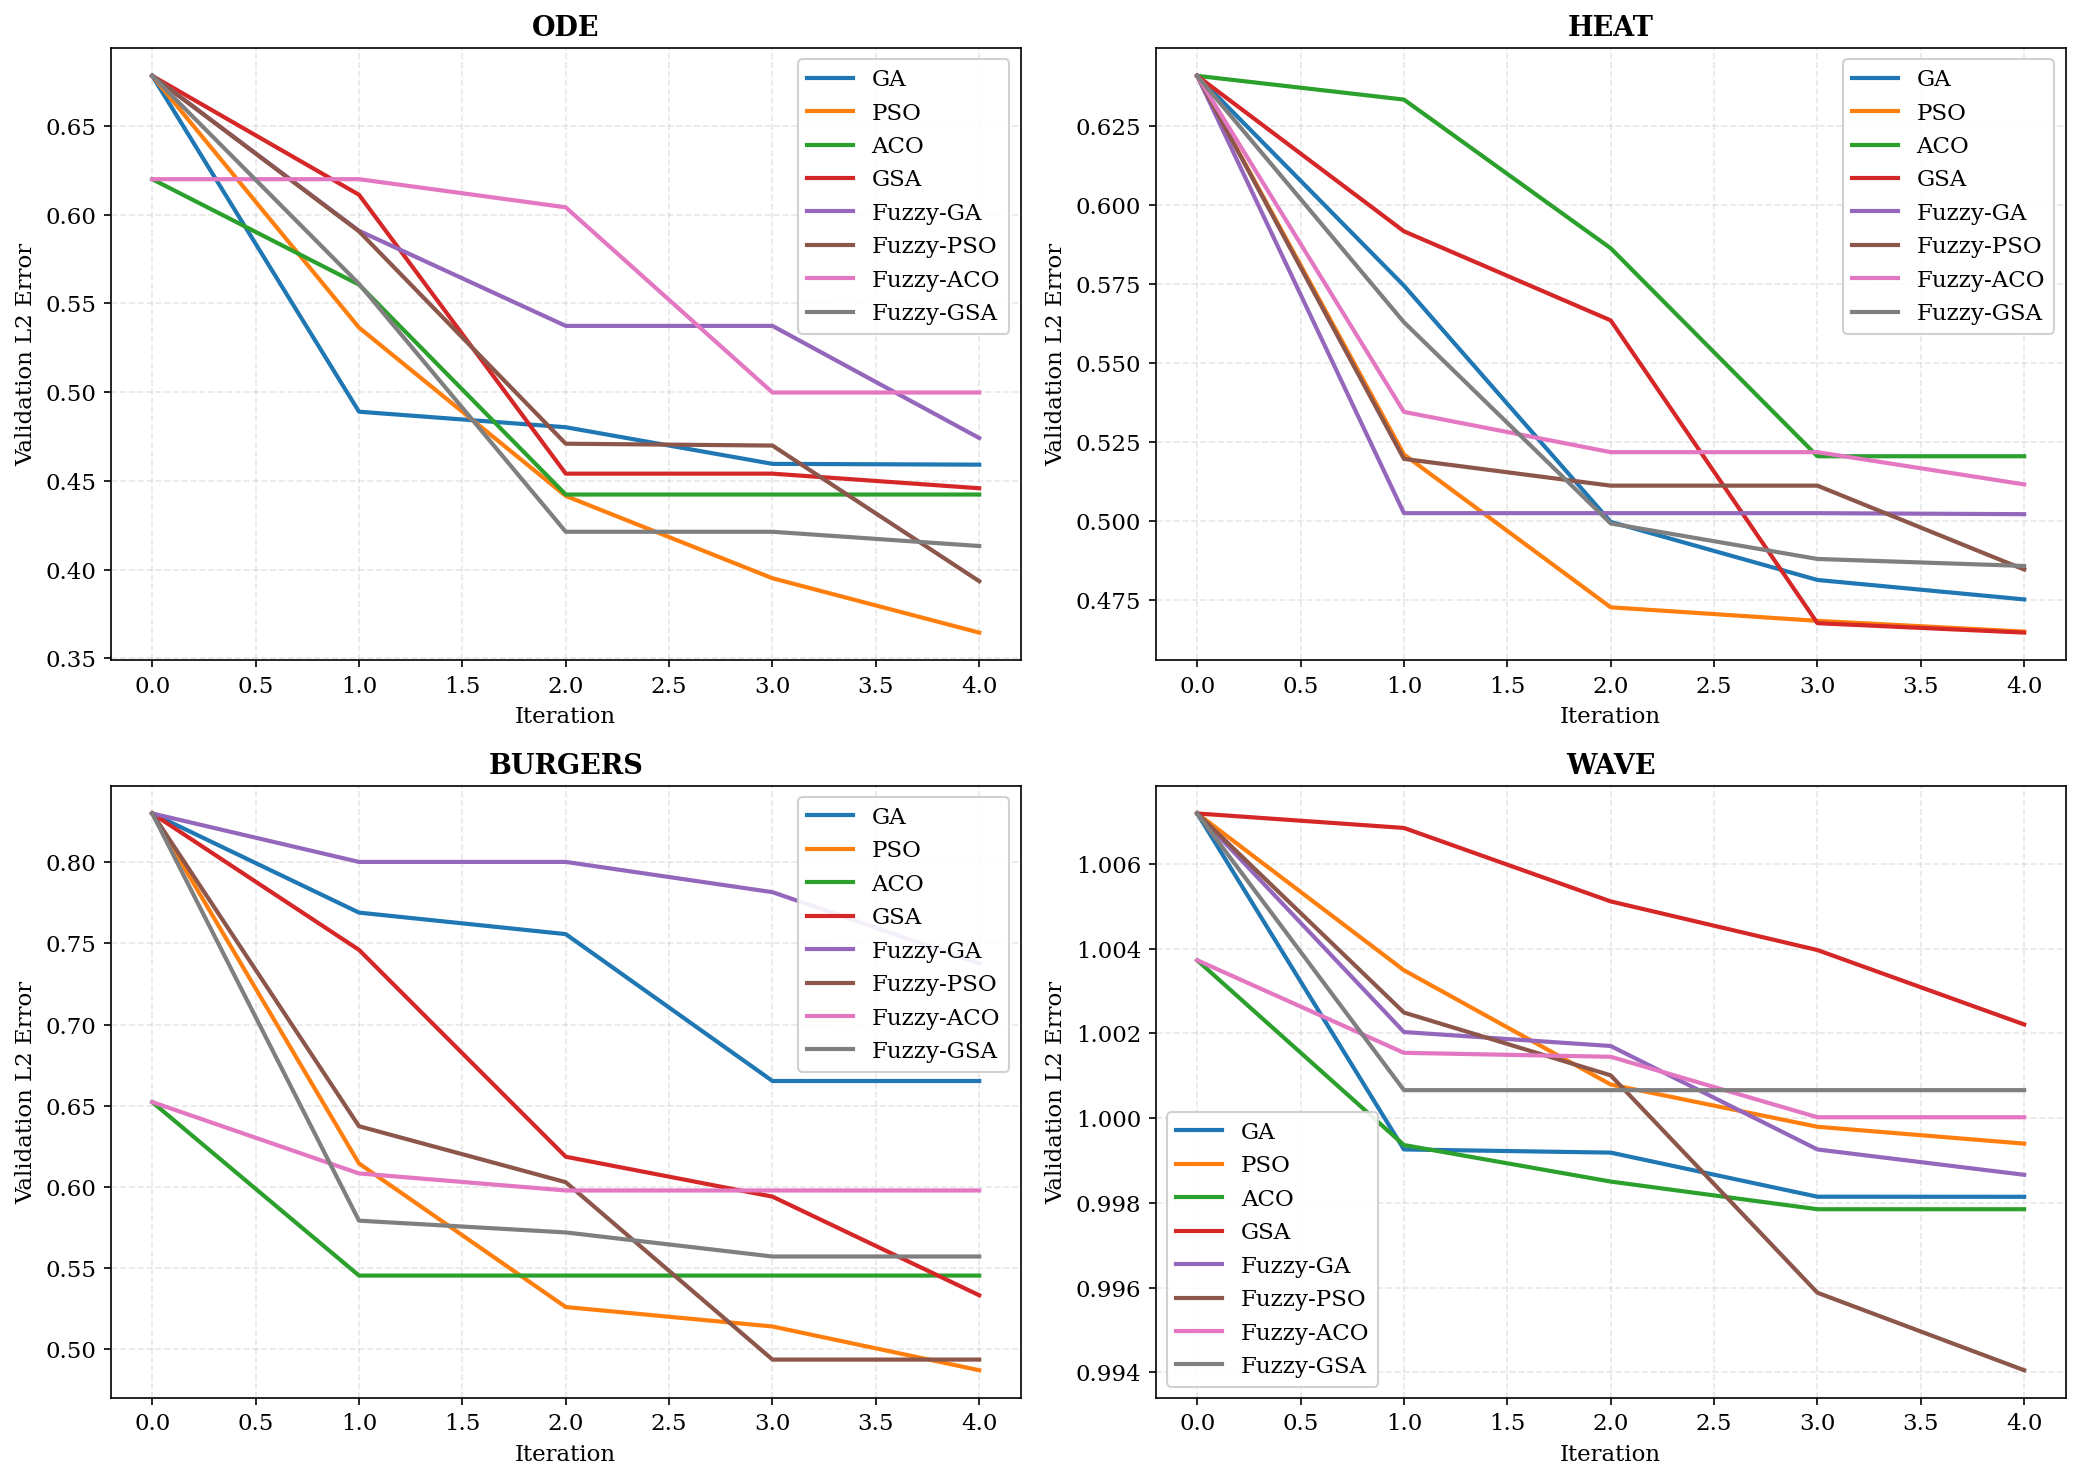

Note: F-MAGSO excluded from per-generation curves (its history is indexed by raw evaluation count, not generation/iteration like the other 8 algorithms). F-MAGSO still appears in performance_comparison.png, heatmaps, and the radar chart.


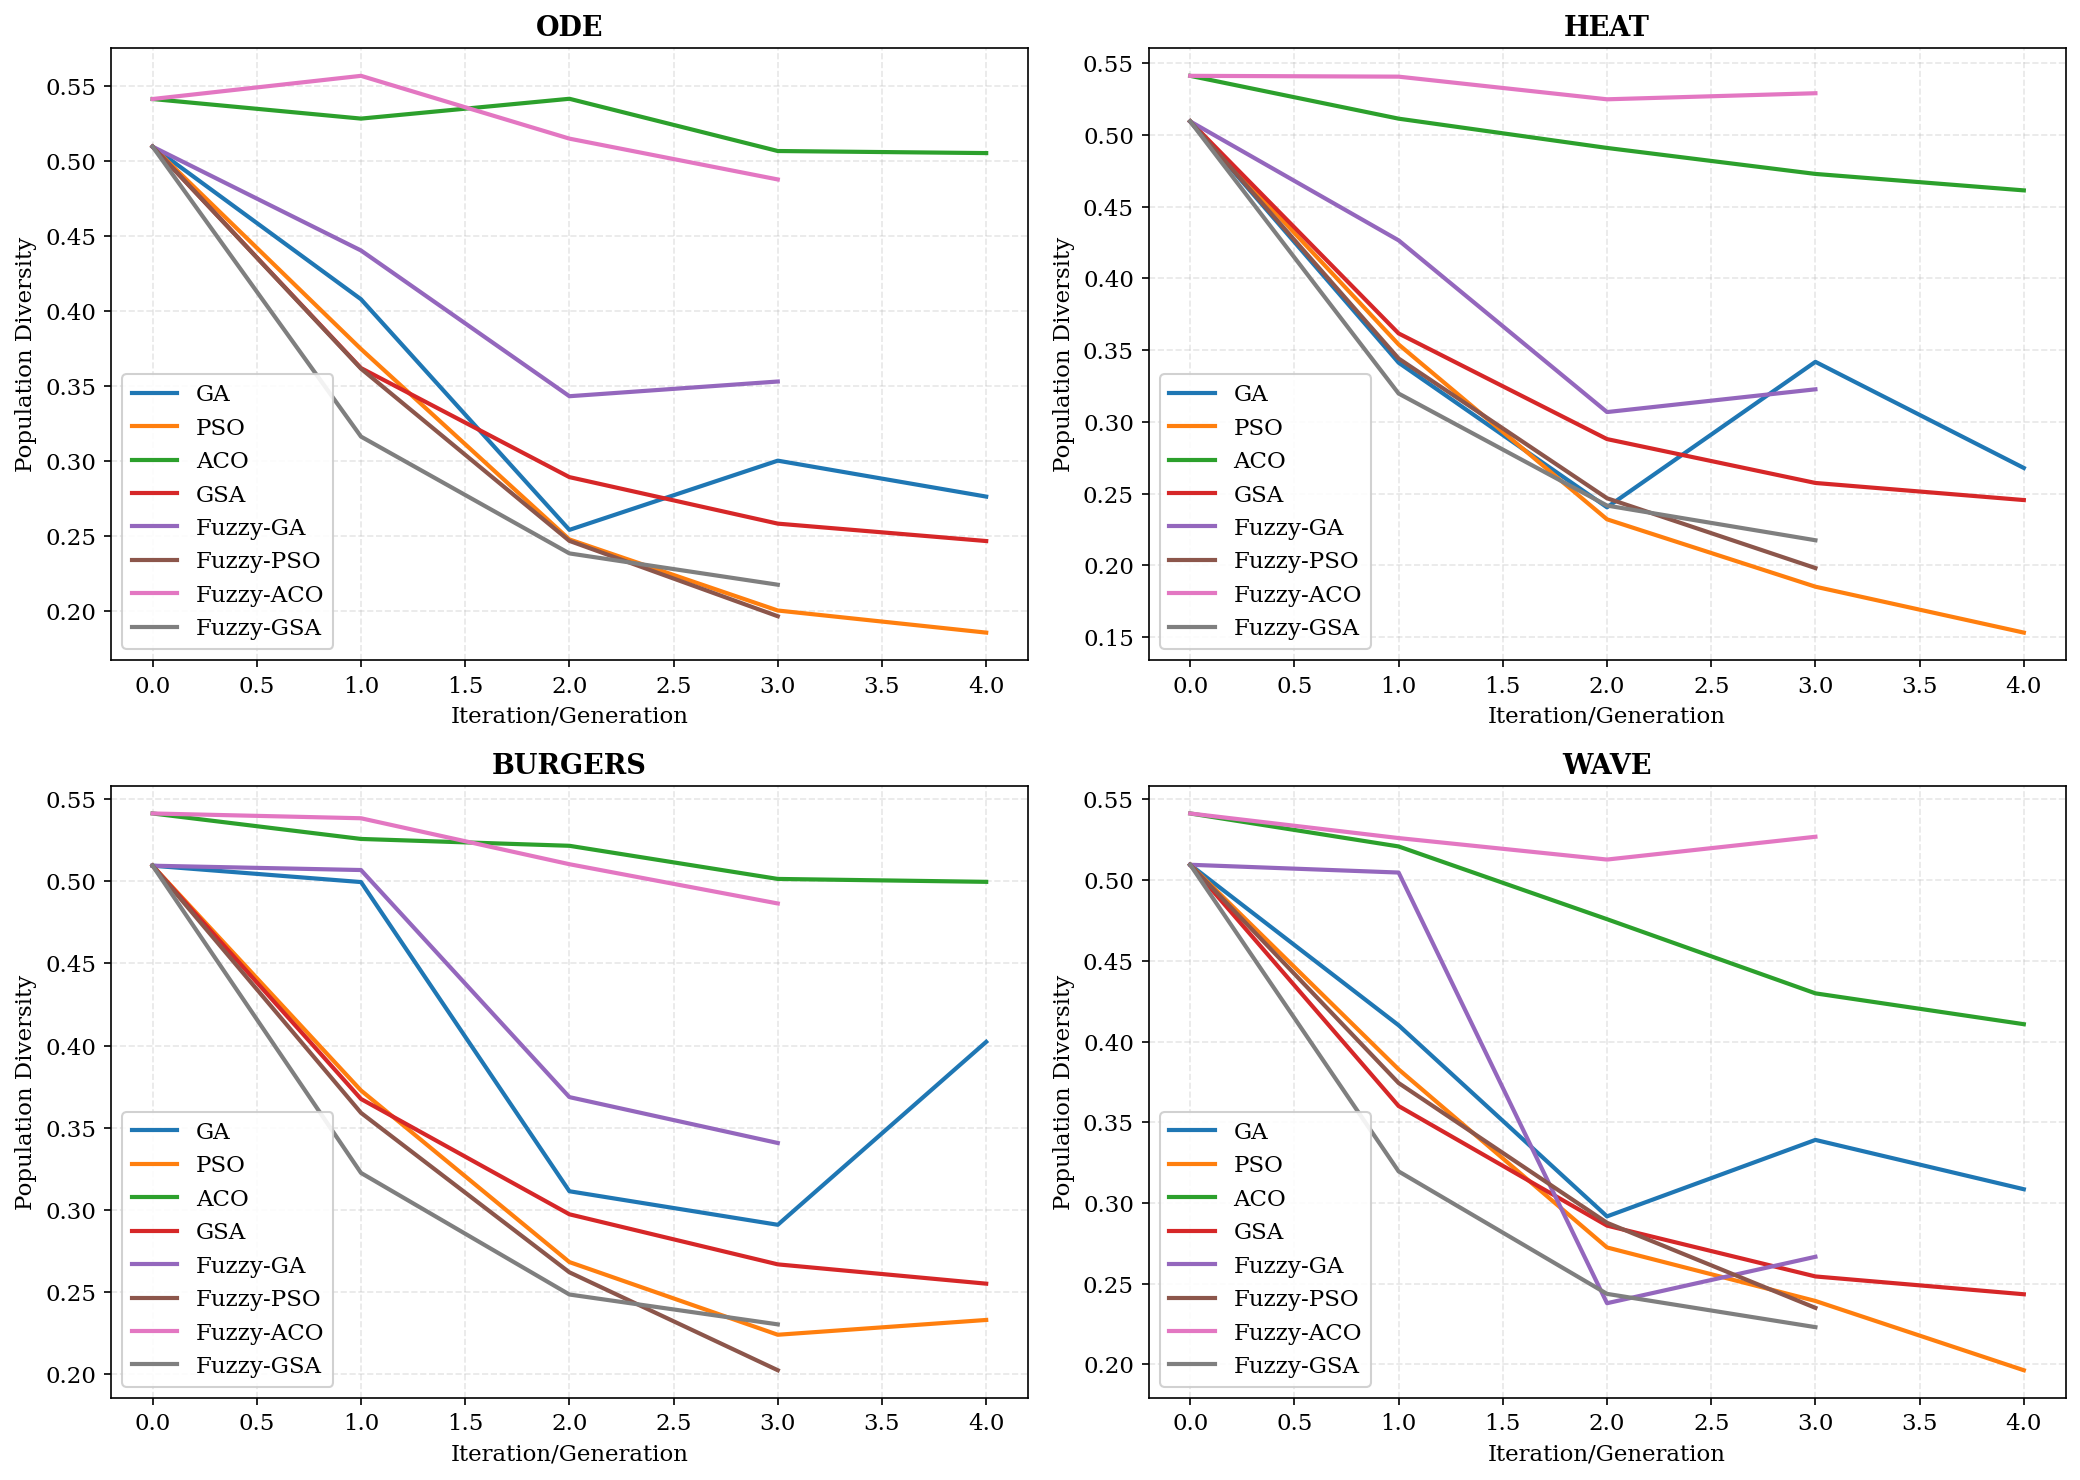

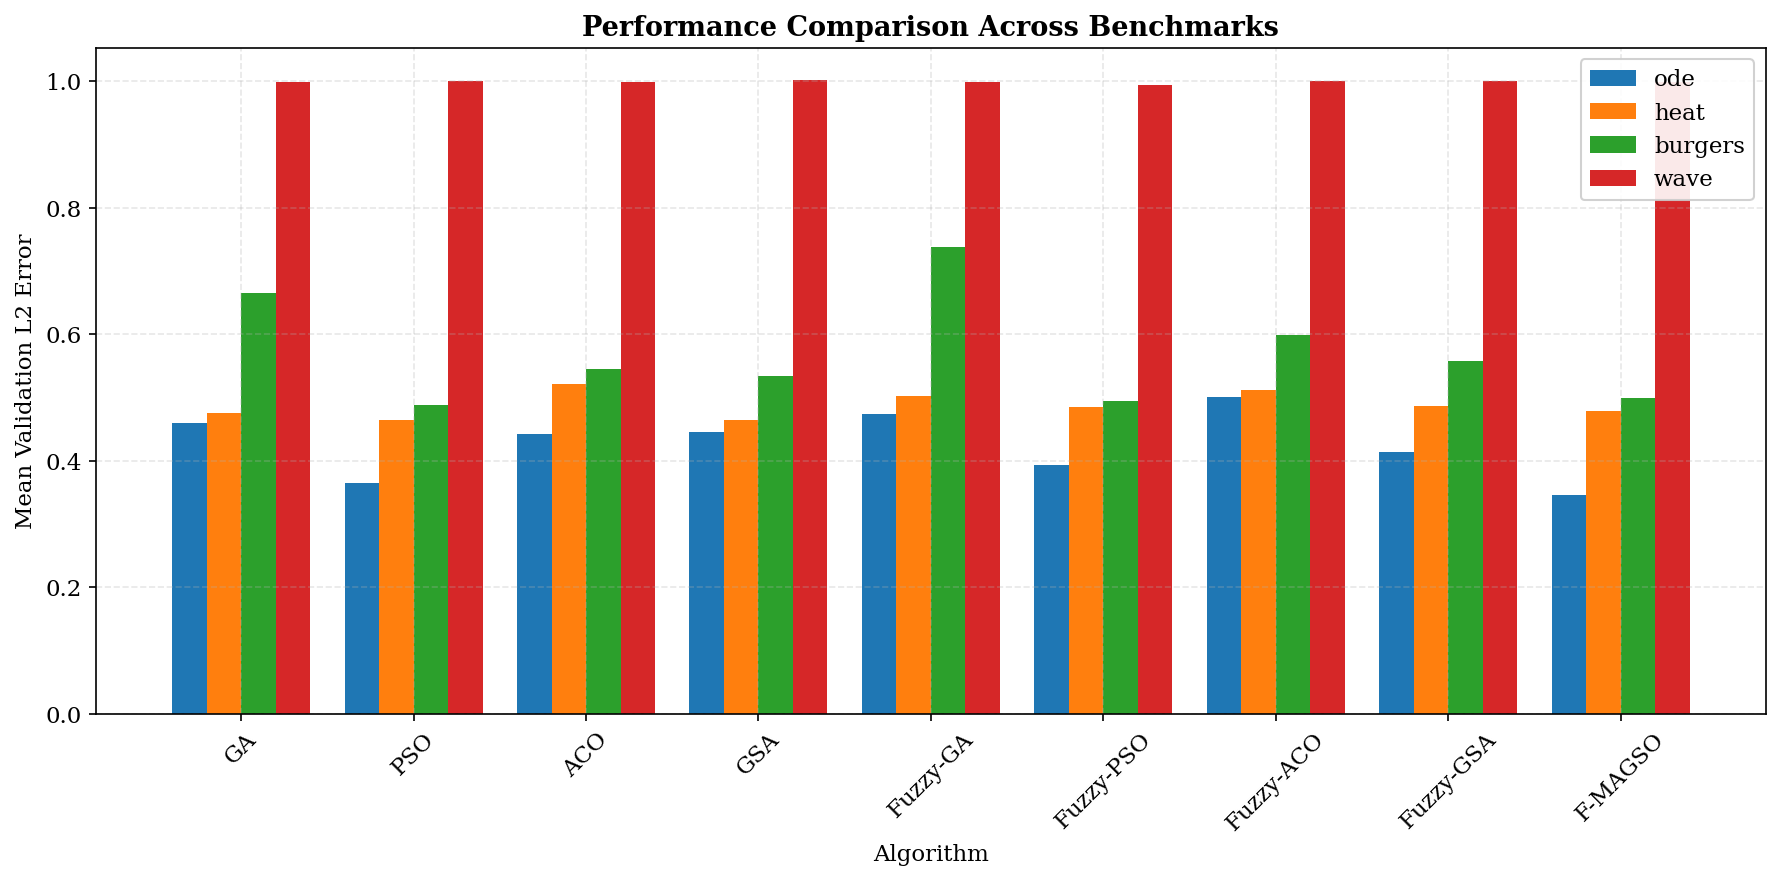

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, bench in enumerate(BENCHMARKS):
    ax = axes[idx // 2, idx % 2]
    for algo in ALGORITHMS:
        vals = [results[f"{algo}_{bench}_{s}"]["history"] for s in SEEDS if f"{algo}_{bench}_{s}" in results]
        if vals:
            min_len = min(len(v) for v in vals)
            mean_hist = np.mean([np.array(v[:min_len]) for v in vals], axis=0)
            x = eval_count_axis(algo, min_len)
            ax.plot(x, mean_hist, label=algo, linewidth=2)
    ax.set_xlabel("Cumulative PINN Evaluations"); ax.set_ylabel("Validation L2 Error"); ax.set_title(bench.upper())
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/convergence_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, bench in enumerate(BENCHMARKS):
    ax = axes[idx // 2, idx % 2]
    for algo in ALGORITHMS:
        div_entry_lists = [results[f"{algo}_{bench}_{s}"]["diversity_history"]
                           for s in SEEDS if f"{algo}_{bench}_{s}" in results
                           and results[f"{algo}_{bench}_{s}"].get("diversity_history")]
        if div_entry_lists:
            min_len = min(len(d) for d in div_entry_lists)
            divs = [[e["diversity"] for e in d[:min_len]] for d in div_entry_lists]
            mean_div = np.mean([np.array(d) for d in divs], axis=0)
            # Use the actual eval_count stored per entry when present (F-MAGSO's
            # diversity_history is appended once per while-loop pass, not once per
            # eval like its history array, so the generic per-step formula would
            # be wrong here); otherwise fall back to the generational formula.
            if "eval_count" in div_entry_lists[0][0]:
                x = np.array([e["eval_count"] for e in div_entry_lists[0][:min_len]])
            else:
                x = eval_count_axis(algo, min_len)
            ax.plot(x, mean_div, label=algo, linewidth=2)
    ax.set_xlabel("Cumulative PINN Evaluations"); ax.set_ylabel("Population Diversity"); ax.set_title(bench.upper())
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/diversity_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(ALGORITHMS)); width = 0.2
for idx, bench in enumerate(BENCHMARKS):
    means = [comparison_results.get(a, {}).get(bench, {}).get("mean_l2", 0.0) for a in ALGORITHMS]
    ax.bar(x_pos + idx * width, means, width, label=bench)
ax.set_xlabel("Algorithm"); ax.set_ylabel("Mean Validation L2 Error")
ax.set_title("Performance Comparison Across Benchmarks")
ax.set_xticks(x_pos + width * 1.5); ax.set_xticklabels(ALGORITHMS, rotation=45)
ax.legend(); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/performance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ---- Research-grade: Cumulative-Evaluations Diversity vs Accuracy Evolution ----
# All algorithms share the same x-axis unit (cumulative real PINN training calls),
# so curves are directly comparable in computational cost - including F-MAGSO,
# whose eval-budget design otherwise has a different step granularity than the
# generational algorithms (GA/PSO/ACO/GSA and their fuzzy variants).

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
algo_colors = plt.cm.tab10(np.linspace(0, 1, len(ALGORITHMS)))
ALGO_COLORS.update({a: algo_colors[i] for i, a in enumerate(ALGORITHMS)})

for idx, bench in enumerate(BENCHMARKS):
    ax_acc = axes[idx // 2, idx % 2]
    ax_div = ax_acc.twinx()

    for algo in ALGORITHMS:
        acc_runs = [results[f"{algo}_{bench}_{s}"]["history"]
                    for s in SEEDS if f"{algo}_{bench}_{s}" in results]
        div_entry_lists = [results[f"{algo}_{bench}_{s}"]["diversity_history"]
                           for s in SEEDS if f"{algo}_{bench}_{s}" in results
                           and results[f"{algo}_{bench}_{s}"].get("diversity_history")]

        color = ALGO_COLORS[algo]
        if acc_runs:
            min_len = min(len(r) for r in acc_runs)
            acc_arr = np.array([r[:min_len] for r in acc_runs])
            mean_acc = np.mean(acc_arr, axis=0)
            std_acc = np.std(acc_arr, axis=0)
            x = eval_count_axis(algo, min_len)
            ax_acc.plot(x, mean_acc, "-", color=color, linewidth=2.0, label=f"{algo} (L2)")
            ax_acc.fill_between(x, mean_acc - std_acc, mean_acc + std_acc, color=color, alpha=0.08)

        if div_entry_lists:
            min_len_d = min(len(d) for d in div_entry_lists)
            div_arr = np.array([[e["diversity"] for e in d[:min_len_d]] for d in div_entry_lists])
            mean_div = np.mean(div_arr, axis=0)
            # Same eval_count-vs-formula distinction as the diversity_trajectories plot.
            if "eval_count" in div_entry_lists[0][0]:
                x_d = np.array([e["eval_count"] for e in div_entry_lists[0][:min_len_d]])
            else:
                x_d = eval_count_axis(algo, min_len_d)
            ax_div.plot(x_d, mean_div, "--", color=color, linewidth=1.5, alpha=0.7)

    ax_acc.set_yscale("log")
    ax_acc.set_xlabel("Cumulative PINN Evaluations")
    ax_acc.set_ylabel("Mean Validation L2 Error (log scale, solid)")
    ax_div.set_ylabel("Mean Population Diversity (dashed)")
    ax_div.set_ylim(0, 1)
    ax_acc.set_title(f"{bench.upper()}: Accuracy vs. Diversity Evolution")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=min(5, len(ALGORITHMS)),
           bbox_to_anchor=(0.5, -0.04), fontsize=9)
fig.suptitle("Diversity vs. Accuracy Evolution over Cumulative PINN Evaluations (solid=L2 error, dashed=diversity)",
             fontsize=14, fontweight="bold", y=1.0)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/generation_diversity_vs_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

print("Generation-wise diversity-vs-accuracy figure saved (research-grade, 300 DPI, shared evaluation-count x-axis).")

Generation-wise diversity-vs-accuracy figure saved (research-grade, 300 DPI).


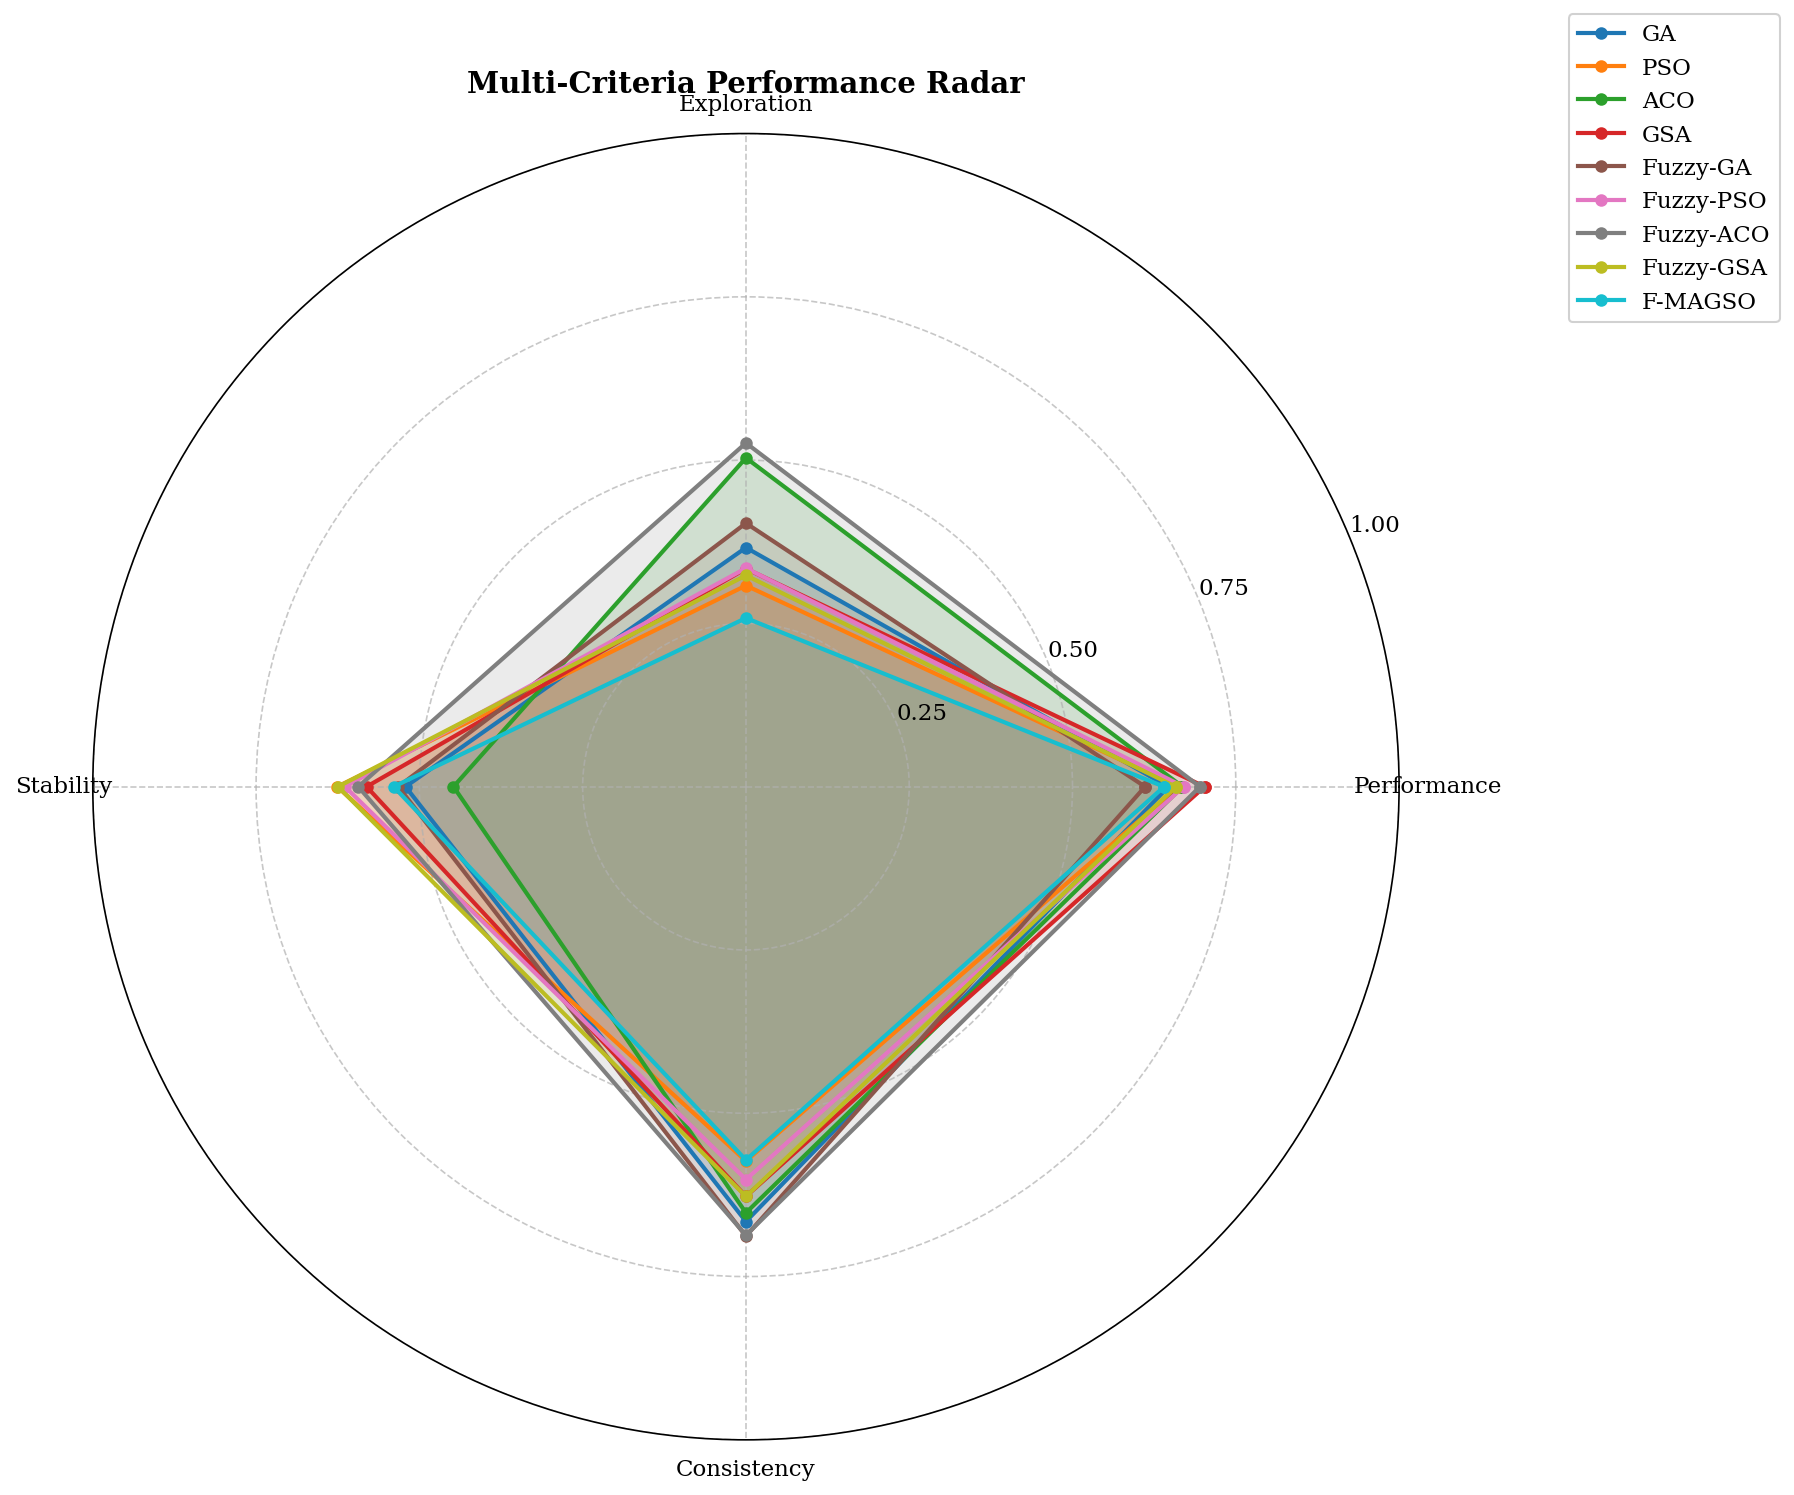

Radar chart saved.


In [ ]:
def compute_radar_scores(comparison_results, ALGORITHMS, BENCHMARKS):
    """Compute multi-criteria scores: Performance, Diversity, Stability, Consistency."""
    radar_data = {}
    for algo in ALGORITHMS:
        scores = {}
        if algo in comparison_results:
            l2_errors = [comparison_results[algo].get(b, {}).get("mean_l2", float("nan")) for b in BENCHMARKS]
            valid_l2 = [x for x in l2_errors if not np.isnan(x)]
            if valid_l2:
                min_l2 = min(valid_l2)
                max_l2 = max(valid_l2)
                if max_l2 > min_l2:
                    perf_score = 1.0 - (np.mean(valid_l2) - min_l2) / (max_l2 - min_l2)
                else:
                    perf_score = 0.5
                scores["Performance"] = float(np.clip(perf_score, 0.0, 1.0))

            divs = [comparison_results[algo].get(b, {}).get("mean_diversity", 0.0) for b in BENCHMARKS]
            scores["Exploration"] = float(np.mean(divs)) if divs else 0.0

            l2_stds = [comparison_results[algo].get(b, {}).get("std_l2", 0.0) for b in BENCHMARKS]
            valid_stds = [x for x in l2_stds if x > 0.0]
            if valid_stds:
                max_std = max(valid_stds)
                stab_score = 1.0 - (np.mean(valid_stds) / max_std) if max_std > 0 else 0.5
                scores["Stability"] = float(np.clip(stab_score, 0.0, 1.0))
            else:
                scores["Stability"] = 0.5

            if valid_l2 and np.mean(valid_l2) > 0:
                cv = np.std(valid_l2) / np.mean(valid_l2)
                consist_score = max(0.0, 1.0 - cv)
                scores["Consistency"] = float(np.clip(consist_score, 0.0, 1.0))
            else:
                scores["Consistency"] = 0.5

        radar_data[algo] = scores
    return radar_data

fig = plt.figure(figsize=(14, 10))
N_criteria = 4
criteria = ["Performance", "Exploration", "Stability", "Consistency"]
angles = [n / float(N_criteria) * 2 * np.pi for n in range(N_criteria)]
angles += angles[:1]

radar_scores = compute_radar_scores(comparison_results, ALGORITHMS, BENCHMARKS)

ax = fig.add_subplot(111, projection="polar")
colors = plt.cm.tab10(np.linspace(0, 1, len(ALGORITHMS)))

for idx, algo in enumerate(ALGORITHMS):
    scores = [radar_scores[algo].get(c, 0.5) for c in criteria]
    scores += scores[:1]
    ax.plot(angles, scores, "o-", linewidth=2, label=algo, color=colors[idx])
    ax.fill(angles, scores, alpha=0.15, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(criteria)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.grid(True, linestyle="--", alpha=0.7)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
ax.set_title("Multi-Criteria Performance Radar", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/radar_multi_criteria.png", dpi=150, bbox_inches="tight")
plt.show()

print("Radar chart saved.")

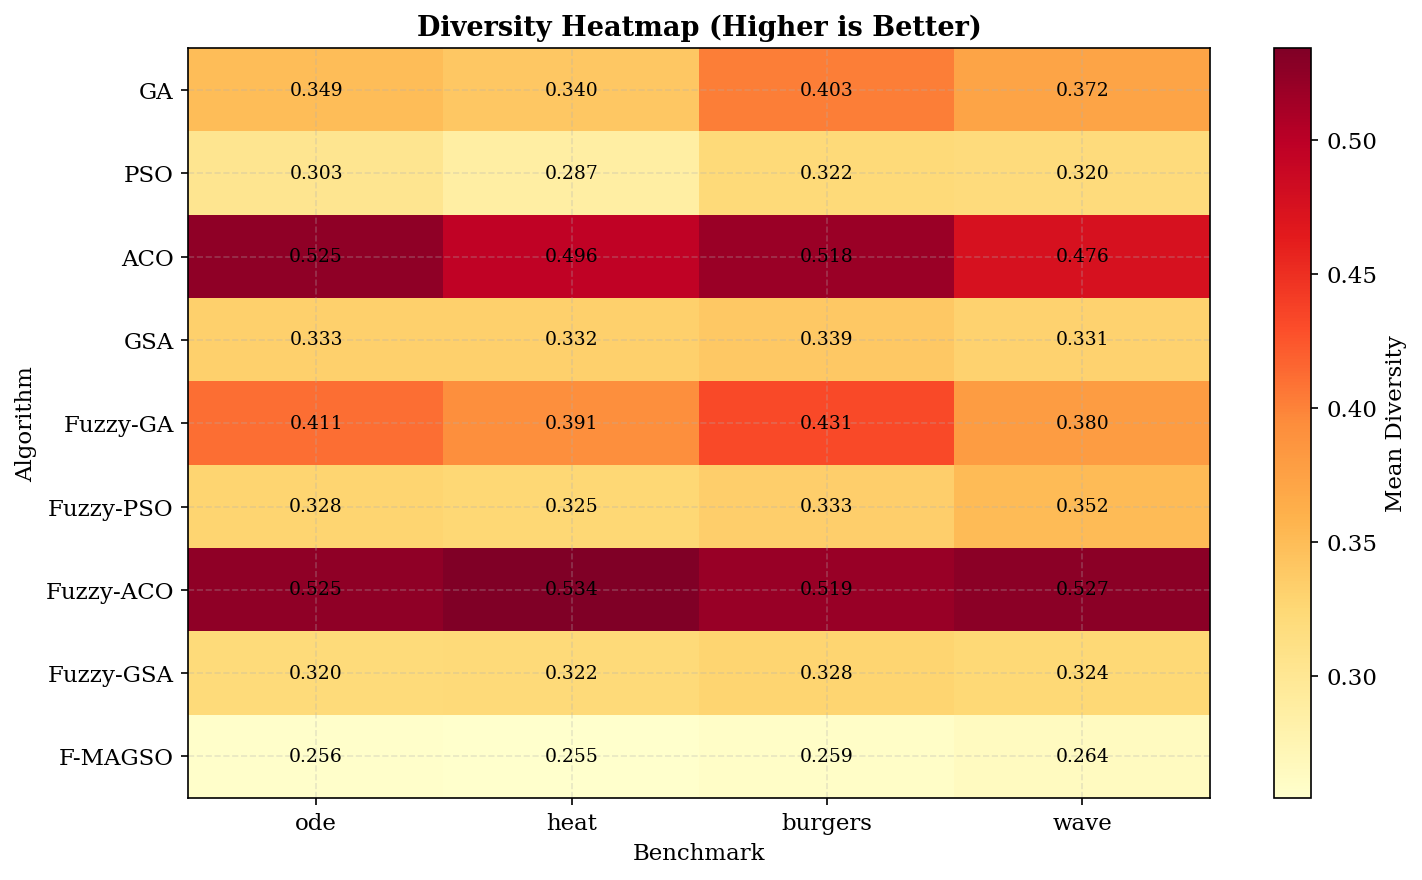

Heatmaps saved.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
data_perf = np.zeros((len(ALGORITHMS), len(BENCHMARKS)))
for i, algo in enumerate(ALGORITHMS):
    for j, bench in enumerate(BENCHMARKS):
        data_perf[i, j] = comparison_results.get(algo, {}).get(bench, {}).get("mean_l2", 0.0)

im = ax.imshow(data_perf, cmap="RdYlGn_r", aspect="auto")
ax.set_xticks(np.arange(len(BENCHMARKS)))
ax.set_yticks(np.arange(len(ALGORITHMS)))
ax.set_xticklabels(BENCHMARKS)
ax.set_yticklabels(ALGORITHMS)
for i in range(len(ALGORITHMS)):
    for j in range(len(BENCHMARKS)):
        ax.text(j, i, f"{data_perf[i, j]:.3f}", ha="center", va="center", color="black", fontsize=9)
ax.set_title("L2 Error Heatmap (Lower is Better)", fontweight="bold")
ax.set_xlabel("Benchmark")
ax.set_ylabel("Algorithm")
plt.colorbar(im, ax=ax, label="Mean L2 Error")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/heatmap_l2_error.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
data_div = np.zeros((len(ALGORITHMS), len(BENCHMARKS)))
for i, algo in enumerate(ALGORITHMS):
    for j, bench in enumerate(BENCHMARKS):
        data_div[i, j] = comparison_results.get(algo, {}).get(bench, {}).get("mean_diversity", 0.0)

im = ax.imshow(data_div, cmap="YlOrRd", aspect="auto")
ax.set_xticks(np.arange(len(BENCHMARKS)))
ax.set_yticks(np.arange(len(ALGORITHMS)))
ax.set_xticklabels(BENCHMARKS)
ax.set_yticklabels(ALGORITHMS)
for i in range(len(ALGORITHMS)):
    for j in range(len(BENCHMARKS)):
        ax.text(j, i, f"{data_div[i, j]:.3f}", ha="center", va="center", color="black", fontsize=9)
ax.set_title("Diversity Heatmap (Higher is Better)", fontweight="bold")
ax.set_xlabel("Benchmark")
ax.set_ylabel("Algorithm")
plt.colorbar(im, ax=ax, label="Mean Diversity")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/heatmap_diversity.png", dpi=150, bbox_inches="tight")
plt.show()

print("Heatmaps saved.")

In [ ]:
report = []
report.append("# PINN HPO Manuscript: HPO for Physics-Informed Neural Networks\n")
report.append(f"Mode: {'QUICK smoke-test (not for publication)' if QUICK_MODE else 'FULL real run'}\n")
report.append("## Experimental Setup\n")
report.append(f"- {len(ALGORITHMS)} algorithms: {', '.join(ALGORITHMS)}")
report.append("- 4 benchmarks: ODE, Heat, Burgers, Wave (real PyTorch PINN training, autograd physics residuals)")
report.append(f"- 3 seeds: {SEEDS}")
report.append(f"- n_steps per training call: {N_STEPS}\n")

report.append("## Results Summary\n")
report.append("| Algorithm | ODE | Heat | Burgers | Wave | Mean |")
report.append("|-----------|-----|------|---------|------|------|")
algo_means = {}
for algo in ALGORITHMS:
    vals = [comparison_results[algo][b]["mean_l2"] for b in BENCHMARKS if b in comparison_results.get(algo, {})]
    if vals:
        algo_means[algo] = np.mean(vals)
        row = f"| {algo} |"
        for b in BENCHMARKS:
            row += f" {comparison_results[algo][b]['mean_l2']:.4f} |" if b in comparison_results[algo] else " - |"
        row += f" {np.mean(vals):.4f} |"
        report.append(row)

report.append("\n## Diversity Analysis\n")
report.append("| Algorithm | Mean Diversity |")
report.append("|-----------|-----------------|")
for algo in ALGORITHMS:
    divs = [comparison_results[algo][b]["mean_diversity"] for b in BENCHMARKS if b in comparison_results.get(algo, {})]
    if divs:
        report.append(f"| {algo} | {np.mean(divs):.4f} |")

report.append("\n## Mean Accuracy Across Run (consistency, not just final luck)\n")
report.append("This measures the average L2 error of EVERY candidate the search tried, not just")
report.append("the final best-found config. A lower value means the algorithm stayed consistently")
report.append("good throughout the search, rather than landing on one lucky good configuration.\n")
report.append("| Algorithm | Final L2 (best found) | Mean L2 Across Run (all candidates) |")
report.append("|-----------|------------------------|---------------------------------------|")
for algo in ALGORITHMS:
    finals = [comparison_results[algo][b]["mean_l2"] for b in BENCHMARKS if b in comparison_results.get(algo, {})]
    runs = [comparison_results[algo][b]["mean_accuracy_across_run"] for b in BENCHMARKS
            if b in comparison_results.get(algo, {}) and not np.isnan(comparison_results[algo][b]["mean_accuracy_across_run"])]
    if finals and runs:
        report.append(f"| {algo} | {np.mean(finals):.4f} | {np.mean(runs):.4f} |")

if algo_means:
    best_algo = min(algo_means, key=algo_means.get)
    report.append(f"\n## Key Findings\n")
    report.append(f"- Best overall algorithm: {best_algo} (mean L2 error: {algo_means[best_algo]:.4f})")
    report.append(f"- With only {len(SEEDS)} seeds this is not statistically powered for significance testing; "
                  f"rank differences should be read as descriptive.")

report_text = "\n".join(report)
with open(f"{OUTPUT_DIR}/MANUSCRIPT_REPORT.md", 'w') as f:
    f.write(report_text)
print(report_text)

# PINN HPO Manuscript: HPO for Physics-Informed Neural Networks

Mode: QUICK smoke-test (not for publication)

## Experimental Setup

- 6 algorithms: GA, PSO, ACO, Fuzzy-GA, Fuzzy-PSO, Fuzzy-ACO
- 4 benchmarks: ODE, Heat, Burgers, Wave (real PyTorch PINN training, autograd physics residuals)
- 3 seeds: [0, 1, 2]
- n_steps per training call: 1

## Results Summary

| Algorithm | ODE | Heat | Burgers | Wave | Mean |
|-----------|-----|------|---------|------|------|
| GA | 0.4591 | 0.4752 | 0.6652 | 0.9981 | 0.6494 |
| PSO | 0.3645 | 0.4650 | 0.4872 | 0.9994 | 0.5790 |
| ACO | 0.4423 | 0.5205 | 0.5455 | 0.9978 | 0.6265 |
| GSA | 0.4458 | 0.4647 | 0.5334 | 1.0022 | 0.6115 |
| Fuzzy-GA | 0.4741 | 0.5021 | 0.7376 | 0.9987 | 0.6781 |
| Fuzzy-PSO | 0.3934 | 0.4846 | 0.4938 | 0.9940 | 0.5915 |
| Fuzzy-ACO | 0.4998 | 0.5116 | 0.5979 | 1.0000 | 0.6523 |
| Fuzzy-GSA | 0.4133 | 0.4858 | 0.5572 | 1.0007 | 0.6142 |
| F-MAGSO | 0.3454 | 0.4783 | 0.4993 | 0.9989 | 0.5805 |

## Diversity Analysis

| Alg

In [ ]:
import shutil

# IMPORTANT: the zip is written OUTSIDE OUTPUT_DIR (as a sibling), not inside it.
# Writing the zip inside the directory being zipped means re-running this cell on a
# second pass (e.g., after a Colab disconnect/reconnect) would recursively include the
# previous zip inside the new one, compounding in size on every re-run.
zip_base = f"{OUTPUT_DIR.rstrip('/')}_export"
shutil.make_archive(zip_base, 'zip', OUTPUT_DIR)
zip_path = f"{zip_base}.zip"
print(f"Results packaged: {zip_path}")
print(f"Size: {os.path.getsize(zip_path) / (1024**2):.1f} MB")

try:
    from google.colab import files
    files.download(zip_path)
except ImportError:
    print("Not running in Colab -- download skipped. File is at:", zip_path)

## Notes

- **QUICK_MODE**: Run once with `QUICK_MODE = True` (Configuration cell) to confirm
  everything executes end-to-end (a few minutes). Then set `QUICK_MODE = False` and
  **Runtime â†’ Run all** again for the real multi-hour benchmark.
- All four benchmark trainers (ODE, Heat, Burgers, Wave) use **real PyTorch autograd**
  to compute PDE residuals and train an `MLP` â€” this mirrors `src/training/benchmark_factory.py`
  exactly, no synthetic placeholder metrics.
- Results are saved incrementally to `/content/pinn_hpo_results/` as each task finishes,
  so a Colab disconnect part-way through does not lose completed tasks (re-running the
  "Run all tasks" cell will simply overwrite/redo â€” no resume logic is included).
- If Colab disconnects on a free-tier session during the full run, consider Colab Pro
  for longer uninterrupted runtimes, or split `BENCHMARKS`/`ALGORITHMS` into smaller
  chunks and run sequentially across sessions.

- **Run log**: every completed task appends a line to `run_log.txt` (human-readable) and `run_log.jsonl` (structured, one JSON object per task) as it finishes, so you can monitor progress or audit timing/results without waiting for the whole run to end.
- **Generation-wise diversity vs accuracy plot**: `generation_diversity_vs_accuracy.png` overlays mean L2 error (log scale, solid) and mean population diversity (dashed) per generation/iteration for every algorithm, per benchmark â€” useful for showing the exploration-to-exploitation transition in the manuscript.
- **Radar + heatmaps**: `radar_multi_criteria.png` scores every algorithm on Performance/Exploration/Stability/Consistency; `heatmap_l2_error.png` and `heatmap_diversity.png` give algorithm Ã— benchmark grids at a glance.